In [ ]:
!pip install openpyxl

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 데이터 읽어오기 및 전처리</mark></b></span><br><br>

<b>[변수 및 환경 설정]</b><br>
• 아무것도 건들지 않은 파일 변수 <b>raw</b>, 문제 있는 수집세션만 삭제한 거 <b>not_processed</b>, 전처리 다한거 <b>df</b><br>
• <b>datasets 하위폴더</b> 만들고 내부에 데이터 전부 넣고 코드 시작<br>
• <b>첫 두 개의 데이터 파일은 수집시간 잘못됨</b> - 이거 삭제하는 것까지 <b>not_processed</b><br><br>

<span style="font-size: 24px;"><b><mark>📌 df 처리</mark></b></span><br><br>

<b>[결측치 및 0값 처리 로직]</b><br>
• <b>로직: viewer_count가 0인 것</b>은 확실한 결측치(0.02%) 차지하므로 <b>MCAR로 판단하고 선형보간</b><br>
• <b>chat_count가 0인 것들 처리</b>는 <b>['run_id', 'broad_no']</b>로 묶은 방송 세션 전부가 0인 것들은 <b>행동분석에서는 제외</b>하고, <b>QC bucket(df_zero_bucket)</b>으로 따로 보존<br>
• <b>avg_msg_len이 0인 것</b>은 전부 chat이 없어서 발생 -> <b>0으로 채워넣음</b><br><br>

<b>[세션 정보 및 결측 특성]</b><br>
• 최종 EDA의 세션 단위는 <b>['run_id', 'broad_no']</b>로 정의한다. 즉, 하나의 수집 window 안에서 실제 방송 ID별 viewer-chat 흐름을 본다.<br>
• 각 방송 세션의 첫 minute은 이전 시점이 없으므로 <b>delta_viewer_1m</b>, <b>delta_chat_1m</b> 결측이 자연스럽게 발생한다.<br>
• 전체 chat_count가 0인 방송 세션은 일반 행동분석에서는 제외하고 <b>QC bucket(df_zero_bucket)</b>으로 따로 보존한다.<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b> 제일 중요한 데이터 특성: 심하게 skewed된 데이터셋이다. 웬만하면 log를 씌워서 분석</b></span>
</div>

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 표 출력/CSV/Excel 저장 시 float 계열 숫자는 소수점 3자리로 통일한다.
# 주의: pandas display 설정만 바꾸면 화면 출력만 바뀌고 저장 파일에는 원래 float가 남는다.
TABLE_DECIMALS = 3
pd.set_option("display.float_format", lambda x: f"{x:.{TABLE_DECIMALS}f}")

ID_LIKE_COLS = {
    "run_id", "broad_no", "feature_id", "chat_id", "snapshot_id",
    "k", "cluster", "kmeans_cluster", "model_cluster", "session_type_cluster",
    "n", "n_sessions", "n_minutes", "n_rows", "result",
    "rule_score", "max_zero_run", "candidate_minutes", "candidate_intervals"
}

def _round_numeric_for_export(table, decimals=TABLE_DECIMALS):
    """
    화면 출력과 저장 파일의 소수점 자릿수를 일관되게 맞춘다.
    - float column: 소수점 decimals 자리로 round
    - ID/count처럼 정수 의미가 강한 column: 정수형 유지
    """
    if isinstance(table, pd.Series):
        out = table.to_frame().copy()
    else:
        out = table.copy()

    for col in out.columns:
        if not pd.api.types.is_numeric_dtype(out[col]):
            continue

        # ID/count 성격의 column은 소수점이 붙지 않도록 정수형으로 유지
        if str(col) in ID_LIKE_COLS:
            s = out[col]
            if s.notna().all() and np.allclose(s.astype(float), np.round(s.astype(float))):
                out[col] = s.astype("Int64")
            else:
                out[col] = s.round(decimals)
        elif pd.api.types.is_float_dtype(out[col]):
            out[col] = out[col].round(decimals)

    return out

# 발표용 그래프/표 저장 폴더
FIG_SAVE_DIR = Path.cwd() / "eda_slide_plots"
TABLE_SAVE_DIR = Path.cwd() / "eda_slide_tables"
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 필요한 발표용 출력만 명시적으로 저장한다.
def save_fig(fig, filename):
    path = FIG_SAVE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"saved figure: {path}")
    return path

def save_table(table, filename):
    path = TABLE_SAVE_DIR / filename
    table_to_save = _round_numeric_for_export(table)
    table_to_save.to_csv(
        path,
        index=False,
        encoding="utf-8-sig",
        float_format=f"%.{TABLE_DECIMALS}f"
    )
    print(f"saved table: {path}")
    return path

print(f"EDA slide plot folder: {FIG_SAVE_DIR}")
print(f"EDA slide table folder: {TABLE_SAVE_DIR}")

# 총 20개의 파일이 있고 파일의 특성상 
# 내부에 시간대는 연속되지만 session별로 streamer가 연속되지 않는다.
# 일단 전부 읽어오고 추후 처리

# 해당 파일명 형태와 같은 모든 것들 폴더에서 읽어옴
def file_reading(dir, file_name):
    DATA_DIR = Path(dir)
    files = sorted(DATA_DIR.glob(file_name))

    if len(files) == 0:
        raise FileNotFoundError("*번째의 데이터파일 없음")
    frames = []

    for f in files:
        tmp = pd.read_excel(f)
        # 파일명도 새 column으로 저장
        tmp["source_file"] = f.name

        # 파일 내부에 run_id가 없거나 전부 비어 있으면 파일명에서 추출
        if "run_id" not in tmp.columns or tmp["run_id"].isna().all():
            m = re.search(r"Run_(\d+)_Features", f.name)
            tmp["run_id"] = int(m.group(1)) if m else np.nan

        frames.append(tmp)

    raw = pd.concat(frames, ignore_index=True)
    meta_data = pd.DataFrame({"loaded_file_cnt":[len(files)], 
                   "row_cnt": [len(raw)],
                   "column_cnt" : [raw.shape[1]]})
    return raw , meta_data

raw, meta_data = file_reading("./datasets","Run_*_Features.xlsx")

# 파일 20개 읽음, row 20519개, column 18개
print(meta_data)
print(raw.head(3))


EDA slide plot folder: c:\Users\simon\dm_project_2026\DM_project-1-\my_job\eda_slide_plots
EDA slide table folder: c:\Users\simon\dm_project_2026\DM_project-1-\my_job\eda_slide_tables


FileNotFoundError: *번째의 데이터파일 없음

In [3]:
# raw는 아무것도 안건든 데이터
df = raw.copy()

# EC2 서버의 수집시간 보정
df["minute_ts"] = pd.to_datetime(df["minute_ts"], errors="coerce")
df["minute_ts"] = df["minute_ts"] + pd.Timedelta(hours= 9)

numeric_cols = [
    "viewer_count_last",
    "chat_count",
    "unique_chatters",
    "avg_msg_len",
    "repeat_msg_ratio",
    "new_chatter_ratio",
    "chat_per_viewer",
    "delta_viewer_1m",
    "delta_chat_1m"
]

# 수집된 수치형 데이터 혹시나 모를 문제 위해 점검
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 순서대로 정렬
df = df.sort_values(
    ["run_id", "broad_no", "minute_ts"]
).reset_index(drop=True)

In [ ]:
df.describe()

In [ ]:
df.info()

In [4]:
# 설계한 수집시간 (17-19), (20-22), (23-01)시에 수집되지 않은 것 거르기 위한 코드

# run_id를 기준으로 그룹화하여 시작 시간(min)과 종료 시간(max) 추출
grouped = df.groupby('run_id')['minute_ts'].agg(['min', 'max']).reset_index()

# 조건에 맞게 포맷팅하는 함수 정의
def format_time_range(row):
    run_id = row['run_id']
    start = row['min']
    end = row['max']
    
    day = start.day
    
    # 시작 시간 파싱
    start_ampm = "오후" if start.hour >= 12 else "오전"
    start_hour = start.hour % 12 or 12
    start_min = f" {start.minute}분" if start.minute > 0 else ""
    
    # 종료 시간 파싱
    end_ampm = "오후" if end.hour >= 12 else "오전"
    end_hour = end.hour % 12 or 12
    end_min = f" {end.minute}분" if end.minute > 0 else ""
    
    # 시작 시간 문자열 조합
    start_str = f"{start_ampm} {start_hour}시{start_min}"
    
    # 종료 시간 문자열 조합 (시작과 끝의 오전/오후가 같으면 뒤쪽 생략)
    if start_ampm == end_ampm:
        end_str = f"{end_hour}시{end_min}"
    else:
        end_str = f"{end_ampm} {end_hour}시{end_min}"
        
    return f"{run_id} -> {day}일 {start_str} ~ {end_str}"

# 데이터프레임에 함수 적용 및 출력
for index, row in grouped.iterrows():
    print(format_time_range(row))

29 -> 13일 오후 11시 27분 ~ 오전 1시 27분
30 -> 14일 오전 2시 ~ 2시 30분
31 -> 14일 오후 5시 ~ 7시 1분
32 -> 14일 오후 8시 ~ 10시 1분
33 -> 14일 오후 11시 ~ 오전 1시
34 -> 15일 오후 5시 ~ 7시
35 -> 15일 오후 8시 ~ 10시
36 -> 15일 오후 11시 ~ 오전 1시
37 -> 16일 오후 5시 ~ 7시 1분
38 -> 16일 오후 8시 ~ 10시
39 -> 16일 오후 11시 ~ 오전 1시
40 -> 17일 오후 5시 ~ 7시
41 -> 17일 오후 8시 ~ 10시
42 -> 17일 오후 11시 ~ 오전 1시
43 -> 18일 오후 5시 ~ 7시
44 -> 18일 오후 8시 ~ 10시
45 -> 18일 오후 11시 ~ 오전 1시
46 -> 19일 오후 5시 ~ 7시
47 -> 19일 오후 8시 ~ 10시
48 -> 19일 오후 11시 ~ 오전 1시


In [5]:
# 초기에 29,30 데이터 파일은 EC2 서버 불안정성 때문에
# 설정한 시간과 완전히 다른 시간에서 데이터가 수집되어 제거 후 진행
df = df[df["run_id"] != 29]
df = df[df["run_id"] != 30]

In [6]:
# 0 결측치처리는 신중히 해야하므로 처리전 파일 저장
not_processed = df.copy()

print(f"data (행,열):  {df.shape[0], df.shape[1]}")
print("======전체 결측치 관찰======")
print(df.isna().sum(),end = "\n\n")
print(f"총 처리해야 할 결측치는 {df.isna().sum().sum()}")
print(f"viewer가 0인 것: {len(df[df['viewer_count_last'] == 0])}")
print(f"chat이   0인 것: {len(df[df['chat_count'] == 0])}")
print(f"결정된 결측 비율 : {round(df['viewer_count_last'].isnull().sum()/len(df)*100,2)}%")

# 33,34, 38, 48 file에서 시청자 수 결측치 발견
vcnt = df.loc[df["viewer_count_last"].isnull()].index.tolist()
for idx in vcnt:
    print(f"위치 {df.loc[idx]['run_id']}", end=" ")

data (행,열):  (19116, 18)
======전체 결측치 관찰======
feature_id              0
broad_no                0
minute_ts               0
user_id                 0
category_id             0
viewer_count_last       4
chat_count              0
unique_chatters         0
avg_msg_len          1736
repeat_msg_ratio        0
new_chatter_ratio       0
chat_per_viewer         0
delta_viewer_1m       189
delta_chat_1m         184
run_id                  0
created_at              0
updated_at              0
source_file             0
dtype: int64

총 처리해야 할 결측치는 2113
viewer가 0인 것: 0
chat이   0인 것: 1736
결정된 결측 비율 : 0.02%
위치 33 위치 34 위치 38 위치 48 

In [7]:
# avg_msg_len 결측은 chat_count=0에서 생긴 구조적 결측이므로 0 처리
# 최종 세션 단위는 실제 방송 세션(run_id, broad_no) 기준으로 통일한다.
df["avg_msg_len"] = df["avg_msg_len"].fillna(0)

SESSION_KEYS = ['run_id', 'broad_no']

# viewer 결측이 있으면 같은 방송 세션 내부에서만 보간하고, 없으면 그대로 둔다.
viewer_missing_before = df['viewer_count_last'].isna().sum()
print('viewer_count_last missing before interpolation:', viewer_missing_before)

if viewer_missing_before > 0:
    df['viewer_count_last'] = (
        df.groupby(SESSION_KEYS)['viewer_count_last']
          .transform(lambda s: s.interpolate(method='linear', limit_direction='both'))
    )

print('viewer_count_last remaining missing:', df['viewer_count_last'].isna().sum())


viewer_count_last missing before interpolation: 4
viewer_count_last remaining missing: 0


In [8]:
df = df.sort_values(SESSION_KEYS + ['minute_ts']).copy()

df['delta_viewer_1m'] = df.groupby(SESSION_KEYS)['viewer_count_last'].diff()
df['delta_chat_1m'] = df.groupby(SESSION_KEYS)['chat_count'].diff()

# 확인용 출력
print(df['delta_viewer_1m'].isnull().sum())
print(df['delta_chat_1m'].isnull().sum())
print(df.isnull().sum())

184
184
feature_id             0
broad_no               0
minute_ts              0
user_id                0
category_id            0
viewer_count_last      0
chat_count             0
unique_chatters        0
avg_msg_len            0
repeat_msg_ratio       0
new_chatter_ratio      0
chat_per_viewer        0
delta_viewer_1m      184
delta_chat_1m        184
run_id                 0
created_at             0
updated_at             0
source_file            0
dtype: int64


In [9]:
# 전체 0-chat 여부는 실제 방송 세션(run_id, broad_no) 기준으로 먼저 진단한다.
all_zero_runs = (
    df.groupby(SESSION_KEYS)['chat_count']
      .apply(lambda x: (x == 0).all())
      .reset_index(name='전체_0_여부')
)

# 0이 연속되는 구간도 서로 다른 방송 세션을 넘나들며 이어지면 안 되므로
# SESSION_KEYS 내부에서만 zero-run length를 계산한다.
def zero_run_length_from_chat(s):
    z = s.eq(0)
    block = z.ne(z.shift()).cumsum()
    return z.groupby(block).cumcount().add(1).where(z, 0).astype(int)

df = df.sort_values(SESSION_KEYS + ['minute_ts']).copy()
df['zero_chat_run_length_check'] = (
    df.groupby(SESSION_KEYS)['chat_count']
      .transform(zero_run_length_from_chat)
)

block_details = (
    df[df['chat_count'].eq(0)]
    .groupby(SESSION_KEYS + ['zero_chat_run_length_check'])
    .agg(
        user_id=('user_id', 'first'),
        연속_길이=('chat_count', 'size'),
        시작_ts=('minute_ts', 'min'),
        종료_ts=('minute_ts', 'max'),
        median_viewer=('viewer_count_last', 'median')
    )
    .reset_index()
    .rename(columns={'zero_chat_run_length_check': 'zero_run_끝시점길이'})
)

block_details = block_details.merge(all_zero_runs, on=SESSION_KEYS, how='left')
block_details = block_details.sort_values(by='연속_길이', ascending=False).reset_index(drop=True)
block_details.index.name = '순번'
block_details = block_details[block_details['연속_길이'] != 1]

print("=== 채팅 0 구간 연속 길이 및 방송 세션 전체 0 여부 ===")
print(block_details)

=== 채팅 0 구간 연속 길이 및 방송 세션 전체 0 여부 ===
     run_id  broad_no  zero_run_끝시점길이                           user_id  \
순번                                                                        
0        37  18387220               1  66d99407a0ad3df28903321ed999954d   
1        37  18387734               1  714205d014f45e311dcfdafcf9e7400f   
2        40  18407049               1  11b9646ffae19d55d923ef3860fee839   
3        40  18400312               1  b8263cd74372864eacb2d5bd16551882   
4        43  18426065               1  ed0ef5729a1cce903c72638cd8062512   
..      ...       ...             ...                               ...   
187      37  18386839              44  123cf2a78842d677e66ec57f3e3039c2   
188      37  18386839              40  123cf2a78842d677e66ec57f3e3039c2   
189      37  18386839              43  123cf2a78842d677e66ec57f3e3039c2   
190      37  18386839              42  123cf2a78842d677e66ec57f3e3039c2   
191      37  18386839              41  123cf2a78842d677e66ec57

In [10]:
# 전체 chat_count가 0인 방송 세션은 일반적인 viewer-chat 행동관계 분석을 왜곡할 수 있다.
# 단, 완전 삭제가 아니라 QC/의심 후보 bucket으로 보존하고,
# 이후 EDA 본 흐름은 df_behavior(전체 0-chat 세션 제외) 기준으로 진행한다.
is_all_zero_group = df.groupby(SESSION_KEYS)['chat_count'].transform(lambda x: (x == 0).all())

df_all = df.copy()
df_zero_bucket = df_all[is_all_zero_group].copy()
df_behavior = df_all[~is_all_zero_group].copy()

zero_session_audit = (
    df_all.groupby(SESSION_KEYS)
          .agg(
              user_id=('user_id', 'first'),
              n_minutes=('minute_ts', 'size'),
              start_ts=('minute_ts', 'min'),
              end_ts=('minute_ts', 'max'),
              median_viewer=('viewer_count_last', 'median'),
              max_viewer=('viewer_count_last', 'max'),
              total_chat=('chat_count', 'sum'),
              zero_chat_rate=('chat_count', lambda s: s.eq(0).mean()),
              all_zero_chat_session=('chat_count', lambda s: s.eq(0).all())
          )
          .reset_index()
          .sort_values(['all_zero_chat_session', 'median_viewer'], ascending=[False, False])
)

# 기존 downstream 코드 호환을 위해, 일반 행동분석용 데이터셋을 df로 사용한다.
df = df_behavior.copy()

# 정제된 df 기준 zero-run 재계산
df = df.sort_values(SESSION_KEYS + ['minute_ts']).copy()
df['zero_chat_run_length_check'] = (
    df.groupby(SESSION_KEYS)['chat_count']
      .transform(zero_run_length_from_chat)
)

block_details = (
    df[df['chat_count'].eq(0)]
    .groupby(SESSION_KEYS + ['zero_chat_run_length_check'])
    .agg(
        user_id=('user_id', 'first'),
        연속_길이=('chat_count', 'size'),
        시작_ts=('minute_ts', 'min'),
        종료_ts=('minute_ts', 'max'),
        median_viewer=('viewer_count_last', 'median')
    )
    .reset_index()
    .rename(columns={'zero_chat_run_length_check': 'zero_run_끝시점길이'})
    .sort_values(by='연속_길이', ascending=False)
    .reset_index(drop=True)
)

block_details.index.name = '순번'

print("=== 전체 0-chat 방송 세션 분리 결과 ===")
print(f"전체 row(df_all): {len(df_all)}")
print(f"행동분석 row(df_behavior): {len(df_behavior)}")
print(f"QC bucket row(df_zero_bucket): {len(df_zero_bucket)}")
print(f"전체 0-chat 방송 세션 수: {int(zero_session_audit['all_zero_chat_session'].sum())}")
print("=== 채팅 0 구간 연속 길이 (전체 0-chat 방송 세션은 QC bucket으로 분리) ===")
print(block_details)
print(f"행동분석에서 제외된 row 수 : {len(df_all)-len(df)}")

display(zero_session_audit.head(20))

=== 전체 0-chat 방송 세션 분리 결과 ===
전체 row(df_all): 19116
행동분석 row(df_behavior): 18457
QC bucket row(df_zero_bucket): 659
전체 0-chat 방송 세션 수: 8
=== 채팅 0 구간 연속 길이 (전체 0-chat 방송 세션은 QC bucket으로 분리) ===
     run_id  broad_no  zero_run_끝시점길이                           user_id  \
순번                                                                        
0        37  18387220               1  66d99407a0ad3df28903321ed999954d   
1        37  18387734               1  714205d014f45e311dcfdafcf9e7400f   
2        40  18407049               1  11b9646ffae19d55d923ef3860fee839   
3        40  18400312               1  b8263cd74372864eacb2d5bd16551882   
4        37  18387220               2  66d99407a0ad3df28903321ed999954d   
..      ...       ...             ...                               ...   
276      40  18386889              24  df434464f7e4802bee47c4b9c88331f7   
277      40  18386889              23  df434464f7e4802bee47c4b9c88331f7   
278      40  18386889              22  df434464f7e4802bee

,run_id,broad_no,user_id,n_minutes,start_ts,end_ts,median_viewer,max_viewer,total_chat,zero_chat_rate,all_zero_chat_session
153,46,18440786,1b0561f3051c10a24b9d8ec9a6cb3374,63,2026-04-19 17:00:00,2026-04-19 18:02:00,3812.000,6220.000,0,1.000,True
158,46,18444703,8a933cb3a86c52aadb2483aa4eed72aa,119,2026-04-19 17:00:00,2026-04-19 18:59:00,3234.000,3636.000,0,1.000,True
42,35,18372217,17aa057a8248b53affe30512a91481f5,119,2026-04-15 20:00:00,2026-04-15 21:59:00,3218.000,3391.000,0,1.000,True
38,34,18372217,17aa057a8248b53affe30512a91481f5,118,2026-04-15 17:00:00,2026-04-15 18:59:00,2652.000,3062.000,0,1.000,True
183,48,18454758,8a933cb3a86c52aadb2483aa4eed72aa,1,2026-04-19 23:00:00,2026-04-19 23:00:00,1074.000,1074.000,0,1.000,True
91,39,18399959,083c66a5cfce51967bcad5c1b0b86e5d,118,2026-04-16 23:00:00,2026-04-17 01:00:00,512.000,560.000,0,1.000,True
58,36,18381688,083c66a5cfce51967bcad5c1b0b86e5d,120,2026-04-15 23:00:00,2026-04-16 01:00:00,505.000,572.000,0,1.000,True
50,35,18381688,083c66a5cfce51967bcad5c1b0b86e5d,1,2026-04-15 21:59:00,2026-04-15 21:59:00,62.000,62.000,0,1.000,True
106,41,18408587,0b33823ac81de48d5b78a38cdbc0ab94,121,2026-04-17 20:00:00,2026-04-17 22:00:00,52368.000,64772.000,49967,0.000,False
72,38,18390913,0b33823ac81de48d5b78a38cdbc0ab94,61,2026-04-16 20:00:00,2026-04-16 21:00:00,19787.000,25407.000,12183,0.000,False


In [11]:
# 세션 정의 audit: user_id + run_id는 검증용, 최종 EDA는 run_id + broad_no 기준
session_audit = (
    df_all.groupby(['run_id', 'user_id'])
          .agg(
              n_broad_no=('broad_no', 'nunique'),
              n_rows=('minute_ts', 'size'),
              start_ts=('minute_ts', 'min'),
              end_ts=('minute_ts', 'max'),
              median_viewer=('viewer_count_last', 'median'),
              total_chat=('chat_count', 'sum')
          )
          .reset_index()
          .sort_values('n_broad_no', ascending=False)
)

affected_keys = session_audit.loc[session_audit['n_broad_no'] > 1, ['run_id', 'user_id']]
affected_rows = df_all.merge(affected_keys, on=['run_id', 'user_id'], how='inner').shape[0]

print("user_id + run_id sessions:", len(session_audit))
print("sessions with multiple broad_no:", (session_audit['n_broad_no'] > 1).sum())
print("affected rows:", affected_rows)
print("최종 EDA는 run_id + broad_no 기준으로 수행")

display(session_audit.head(10))


user_id + run_id sessions: 180
sessions with multiple broad_no: 4
affected rows: 412
최종 EDA는 run_id + broad_no 기준으로 수행


,run_id,user_id,n_broad_no,n_rows,start_ts,end_ts,median_viewer,total_chat
158,46,dcf7dbd0f97a33551d9abb68ee88fe0b,2,89,2026-04-19 17:00:00,2026-04-19 19:00:00,1066.000,2045
70,38,0b33823ac81de48d5b78a38cdbc0ab94,2,121,2026-04-16 20:00:00,2026-04-16 22:00:00,5789.000,15079
110,42,000408038eda5ff54260c2a3b4315e28,2,82,2026-04-17 23:00:00,2026-04-18 01:00:00,405.000,495
40,35,083c66a5cfce51967bcad5c1b0b86e5d,2,120,2026-04-15 20:00:00,2026-04-15 21:59:00,962.000,3744
0,31,06f0973dc983645a69d97a8ceab740eb,1,121,2026-04-14 17:00:00,2026-04-14 19:00:00,595.000,2356
122,43,6cac96d5c9b7a9fd28903aa32fc61749,1,121,2026-04-18 17:00:00,2026-04-18 19:00:00,3272.000,7777
116,42,aed9d6557bebfb21ab3d081b862cdd2d,1,120,2026-04-17 23:00:00,2026-04-18 00:59:00,1530.500,2293
117,42,b044e3a3b9259246bc92e863e7d3f3b8,1,61,2026-04-17 23:00:00,2026-04-18 00:00:00,4541.000,19827
118,42,bbbe4175c62d79e87038583e26bd922d,1,120,2026-04-17 23:00:00,2026-04-18 01:00:00,310.000,690
119,42,f20881fce506174330ecb58342c4c70d,1,2,2026-04-17 23:00:00,2026-04-17 23:01:00,1269.000,6


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 데이터 읽어오기 및 전처리</mark></b></span><br><br>

<span style="font-size: 20px;"><b>1. 목적:</b></span> <b>전체 세션 중에 채팅이 있는 정도를 구하고(0 chat) 해당 세션의 비율이 어느정도인지를 보이기</b><br><br>

<b>[히스토그램 및 박스플롯 시각화]</b><br>
• df에서 0값이 존재하는 것 중에 <b>0이 아닌 챗의 비율을 구하고</b><br>
• 해당 비율을 띄고 있는 <b>['run_id', 'broad_no'] 방송 세션의 묶음 수를 그래프로 그림</b><br>
• <b>히스토그램</b>은 bin수 조절 위해 <b>소수점 버림</b>, <b>boxplot</b>은 <b>소수점 유지한채로 그림</b><br><br>

<span style="color: #e53e3e; font-size: 18px;"><b> 결론: 100% 세션 비율은 코드 실행값(freq_100)으로 확인한다. 전체 0-chat 세션은 이미 QC bucket으로 분리했으므로, 여기서는 행동분석용 방송 세션의 non-zero chat 비율을 본다.</b></span>
</div>

60.8%의 비율로 0 chat 없는 채팅 활발한 방송
saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide1_nonzero_ratio_backup.png


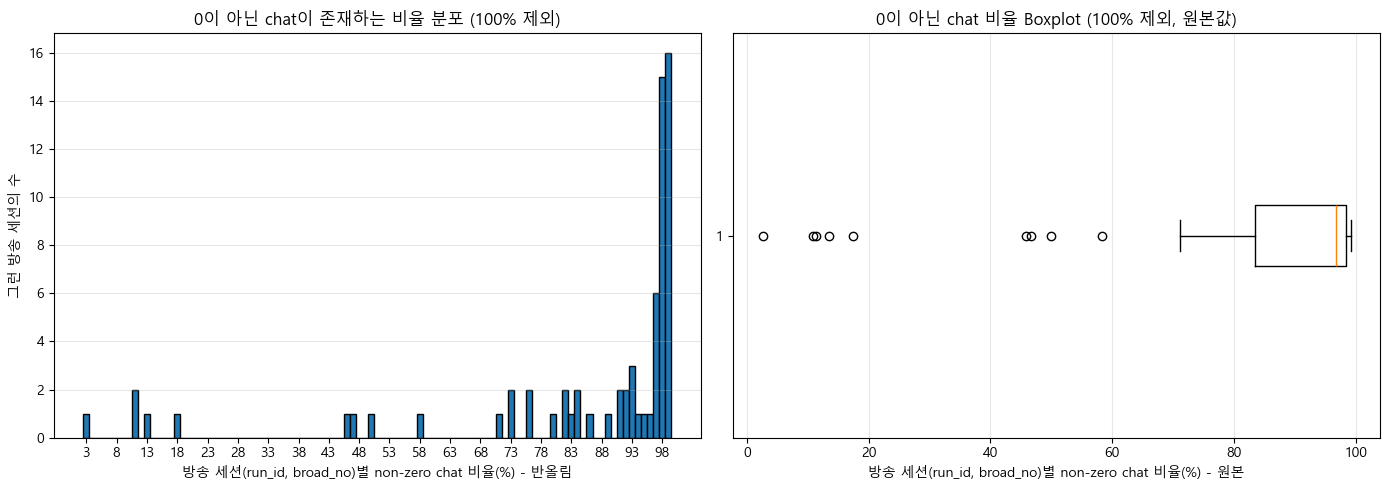

In [12]:
# 방송 세션(run_id, broad_no)별로 "0이 아닌 chat 비율(%)" 계산 - 원본(소수점 유지)
nonzero_percent_raw = (
    df.groupby(SESSION_KEYS)['chat_count']
      .apply(lambda s: (s.ne(0).mean() * 100))
)

# hist용: 반올림한 정수 버전
nonzero_percent_round = nonzero_percent_raw.round().astype(int)

# 100% (= 0 chat이 한 번도 없는 그룹) 비율 출력
freq_100 = (nonzero_percent_round.eq(100).mean() * 100).round(1)
print(f"{freq_100:.1f}%의 비율로 0 chat 없는 채팅 활발한 방송")

# 100% 제외한 plotting용 데이터
hist_data = nonzero_percent_round[nonzero_percent_round != 100]
box_data  = nonzero_percent_raw[nonzero_percent_raw != 100]

# 한국어 폰트 설정 및 -기호, 경고문 안 뜨게 설정
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'MalGun Gothic'
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram: 반올림된 값 사용
# 각 값이 정수 percent이므로 bin도 정수 간격으로 맞춤
bins = np.arange(hist_data.min() - 0.5, hist_data.max() + 1.5, 1)

axes[0].hist(hist_data, bins=bins, edgecolor='black')
axes[0].set_title('0이 아닌 chat이 존재하는 비율 분포 (100% 제외)')
axes[0].set_xlabel('방송 세션(run_id, broad_no)별 non-zero chat 비율(%) - 반올림')
axes[0].set_ylabel('그런 방송 세션의 수')

# x축 눈금이 너무 많으면 5 단위로만 표시
xticks = np.arange(int(hist_data.min()), int(hist_data.max()) + 1, 5)
axes[0].set_xticks(xticks)
axes[0].grid(axis='y', alpha=0.3)

# boxplot: 원본 소수점 비율 사용
axes[1].boxplot(box_data, vert=False)
axes[1].set_title('0이 아닌 chat 비율 Boxplot (100% 제외, 원본값)')
axes[1].set_xlabel('방송 세션(run_id, broad_no)별 non-zero chat 비율(%) - 원본')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, 'slide1_nonzero_ratio_backup.png')
plt.show()

# 도출 결론 => 전체 중에
# 대부분의 표본이 0이 아닌 chat으로 존재하고 있지만 outlier 일부 존재

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 plotting 및 향후 프로젝트를 위해 df의 column 확장</mark></b></span><br><br>

<b>[로그 변환 변수 (Log Scale)]</b><br>
• <b>viewer_log:</b> viewer에 log(1+x) 씌움<br>
• <b>chat_log:</b> chat_count_last에 log(1+x) 씌움<br>
• <b>unique_log:</b> unique_chatters에 log 씌움<br><br>

<b>[차이 및 변화량 변수 (Gap & Delta)]</b><br>
• <b>viewer_chat_log_gap:</b> viewer-chat 간의 로그 차<br>
• <b>viewer_unique_log_gap:</b> viewer와 채팅 친 고유한 사람들 차<br>
• <b>chat_per_viewer_recalc:</b> -로 연산된 시청자수 채팅수 차이<br>
• <b>unique_delta_1m:</b> 고유한 채팅친 사람들의 변화량<br><br>

<b>[0 채팅 추적 및 시간 변수]</b><br>
• <b>zero_chat:</b> 채팅 안 쳤는지 여부 boolean<br>
• <b>zero_chat_run_length:</b> 0채팅 나올 때마다 갱신해서 <b>1씩 증가시킴</b> (ex. 연속되게 3분간 0이면 1, 2, 3)<br>
• <b>minute_idx:</b> 해당 세션에서 <b>지난 시간 표기</b><br><br>

<b>[세션 식별 및 요약 정보]</b><br>
• <b>session_id:</b> run_id와 broad_no 결합 (<b>실제 방송 세션 단위로 묶은 ID</b>)<br>
• <b>session_summary:</b> 세션 정보 요약 정리<br>
• <b>session_summary_10m:</b> <b>10분 이상 수집된 정보만 정상 수집으로 판단</b>하고 10분 필터링함 (대다수가 10분)
</div>

In [13]:
plot_df = df.sort_values(SESSION_KEYS + ['minute_ts']).copy()

plot_df['viewer_log'] = np.log1p(plot_df['viewer_count_last'])
plot_df['chat_log'] = np.log1p(plot_df['chat_count'])
plot_df['unique_log'] = np.log1p(plot_df['unique_chatters'])

plot_df['viewer_chat_log_gap'] = plot_df['viewer_log'] - plot_df['chat_log']
plot_df['viewer_unique_log_gap'] = plot_df['viewer_log'] - plot_df['unique_log']

plot_df['zero_chat'] = plot_df['chat_count'].eq(0)
plot_df['minute_idx'] = plot_df.groupby(SESSION_KEYS).cumcount() + 1

plot_df['chat_per_viewer_recalc'] = np.where(
    plot_df['viewer_count_last'].gt(0),
    plot_df['chat_count'] / plot_df['viewer_count_last'],
    np.nan
)

plot_df['unique_delta_1m'] = (
    plot_df.groupby(SESSION_KEYS)['unique_chatters']
           .diff()
)

def run_length_bool(s):
    s = s.fillna(False).astype(bool)
    block = s.ne(s.shift()).cumsum()
    return s.groupby(block).cumcount().add(1).where(s, 0).astype(int)

plot_df['zero_chat_run_length'] = (
    plot_df.groupby(SESSION_KEYS)['zero_chat']
           .transform(run_length_bool)
)

# 중복 로우로 인한 n_sessions 과대계산 원천 차단을 위해 고유 방송 세션 ID 생성
plot_df['session_id'] = (
    plot_df['run_id'].astype(str) + '_' + plot_df['broad_no'].astype(str)
)

session_summary = (
    plot_df.groupby(SESSION_KEYS)
           .agg(
               user_id=('user_id', 'first'),
               n=('minute_ts', 'size'),
               start_ts=('minute_ts', 'min'),
               end_ts=('minute_ts', 'max'),
               median_viewer=('viewer_count_last', 'median'),
               max_viewer=('viewer_count_last', 'max'),
               mean_chat=('chat_count', 'mean'),
               mean_unique=('unique_chatters', 'mean'),
               zero_chat_rate=('zero_chat', 'mean'),
               max_zero_run=('zero_chat_run_length', 'max'),
               median_gap=('viewer_chat_log_gap', 'median'),
               max_gap=('viewer_chat_log_gap', 'max')
           )
           .reset_index()
)

# bubble plot과 동일한 안정성 기준 유지
# 10분이상 수집된 방송 세션 기준 분석
session_summary_10m = session_summary[session_summary['n'] >= 10].copy()

# 발표용 표: Slide 1 - data quality / analysis cohort
slide1_quality_table = pd.DataFrame([
    {'item': '전체 broadcast session', 'value': df_all.drop_duplicates(SESSION_KEYS).shape[0], 'note': '전체 0-chat 포함'},
    {'item': '전체 0-chat session', 'value': int(zero_session_audit['all_zero_chat_session'].sum()), 'note': '행동분석 제외, QC bucket 보존'},
    {'item': '전체 0-chat minutes', 'value': len(df_zero_bucket), 'note': 'QC bucket rows'},
    {'item': '행동분석 session', 'value': df.drop_duplicates(SESSION_KEYS).shape[0], 'note': '전체 0-chat 제외'},
    {'item': '10분 이상 session', 'value': len(session_summary_10m), 'note': 'clustering/anomaly 분석 기준'},
    {'item': 'user_id+run_id 중 복수 broad_no', 'value': int((session_audit['n_broad_no'] > 1).sum()), 'note': '최종 EDA는 run_id+broad_no 기준'}
])

print('Slide 1 table: data quality / analysis cohort')
display(slide1_quality_table)
save_table(slide1_quality_table, 'slide1_quality_table.csv')

# 발표용 표: Slide 2 - core session metrics
slide2_metric_table = pd.DataFrame([
    {'metric': 'median_viewer', 'median': session_summary_10m['median_viewer'].median(), 'q1': session_summary_10m['median_viewer'].quantile(0.25), 'q3': session_summary_10m['median_viewer'].quantile(0.75)},
    {'metric': 'mean_chat_per_min', 'median': session_summary_10m['mean_chat'].median(), 'q1': session_summary_10m['mean_chat'].quantile(0.25), 'q3': session_summary_10m['mean_chat'].quantile(0.75)},
    {'metric': 'median_gap', 'median': session_summary_10m['median_gap'].median(), 'q1': session_summary_10m['median_gap'].quantile(0.25), 'q3': session_summary_10m['median_gap'].quantile(0.75)},
    {'metric': 'zero_chat_rate', 'median': session_summary_10m['zero_chat_rate'].median(), 'q1': session_summary_10m['zero_chat_rate'].quantile(0.25), 'q3': session_summary_10m['zero_chat_rate'].quantile(0.75)}
]).round(3)

print('Slide 2 table: core session metrics')
display(slide2_metric_table)
save_table(slide2_metric_table, 'slide2_metric_table.csv')


Slide 1 table: data quality / analysis cohort


,item,value,note
0,전체 broadcast session,184,전체 0-chat 포함
1,전체 0-chat session,8,"행동분석 제외, QC bucket 보존"
2,전체 0-chat minutes,659,QC bucket rows
3,행동분석 session,176,전체 0-chat 제외
4,10분 이상 session,173,clustering/anomaly 분석 기준
5,user_id+run_id 중 복수 broad_no,4,최종 EDA는 run_id+broad_no 기준


saved table: c:\Users\simon\dm_project_2026\eda_slide_tables\slide1_quality_table.csv
Slide 2 table: core session metrics


,metric,median,q1,q3
0,median_viewer,633.000,412.000,1271.000
1,mean_chat_per_min,30.890,12.267,64.273
2,median_gap,3.360,2.796,4.042
3,zero_chat_rate,0.000,0.000,0.020


saved table: c:\Users\simon\dm_project_2026\eda_slide_tables\slide2_metric_table.csv


WindowsPath('c:/Users/simon/dm_project_2026/eda_slide_tables/slide2_metric_table.csv')

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 0 count 채팅의 분포 분석</mark></b></span><br><br>

<b>[각 그래프의 분석 의도]</b><br>
<b>1. 연속된 0 chat의 길이:</b> 막대그래프로 확인하며, 길이가 1인 경우가 압도적으로 많으므로 <b>log scale을 적용</b>합니다.<br>
<b>2. 분위수 별 0 chat 분포:</b> viewer_count_last를 전체적으로 <b>10분위로 나누어</b> 해당 분위수 별로 0 chat이 어느 정도 발생하는지 파악합니다.<br>
<b>3. 세션 시점(분) 별 0 chat 분포:</b> 선그래프를 통해 시점 별 분포 추이를 보고, 막대그래프로 <b>해당 분에 남아있는 session의 개수</b>를 함께 확인합니다.<br>
<b>4. zero_run 길이 구간 별 분석:</b> 연속된 0 chat(zero_run)의 길이 구간에 따른 <b>median viewer(중앙값 시청자 수)</b>를 분석합니다.<br><br>

<span style="color: #e53e3e;"><b> 핵심 참고: 데이터의 skew(비대칭 쏠림) 정도가 심하므로, 대표값으로 평균 대신 중앙값(median)을 사용합니다!</b></span>
</div>

saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide1_zero_chat_diagnostics.png


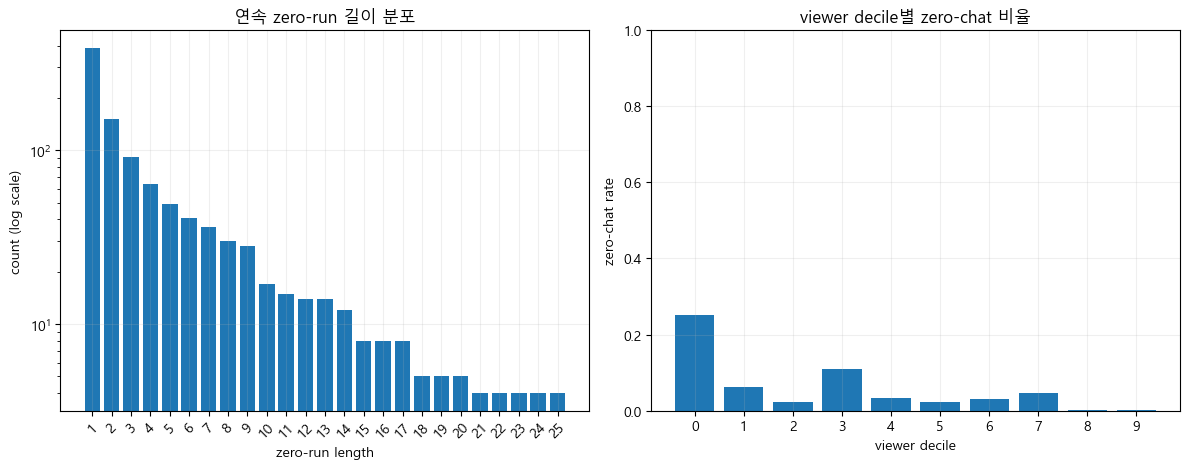

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Slide 1용 핵심 패널 1: 연속 zero-run 길이 분포
zero_runs = plot_df.loc[plot_df['zero_chat'], 'zero_chat_run_length']
dist = zero_runs.value_counts().sort_index().head(25)

axes[0].bar(dist.index.astype(str), dist.values)
axes[0].set_title('연속 zero-run 길이 분포')
axes[0].set_xlabel('zero-run length')
axes[0].set_ylabel('count (log scale)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.2)

# Slide 1용 핵심 패널 2: viewer 분위별 zero-chat 비율
tmp = plot_df.dropna(subset=['viewer_count_last']).copy()
tmp['viewer_bin'] = pd.qcut(
    tmp['viewer_count_last'].rank(method='first'),
    q=10,
    labels=False,
    duplicates='drop'
)
zero_rate_by_bin = tmp.groupby('viewer_bin')['zero_chat'].mean()

axes[1].bar(zero_rate_by_bin.index.astype(str), zero_rate_by_bin.values)
axes[1].set_title('viewer decile별 zero-chat 비율')
axes[1].set_xlabel('viewer decile')
axes[1].set_ylabel('zero-chat rate')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
save_fig(fig, 'slide1_zero_chat_diagnostics.png')
plt.show()


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 개별변수의 분포를 재점검</mark></b></span><br><br>

<b>극도로 skewed</b>되어있음을 미리 체크했으므로 <b>log로 그래프를 그리는 것을 원칙</b>으로 한다.<br>
특히 <b>zero_chat_run_length</b>는 0값 자체가 정상채팅보다 적어 <b>0에서의 빈도수가 압도적으로 높아 log로 y scale을 조정</b>
</div>

saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide2_distribution_core.png


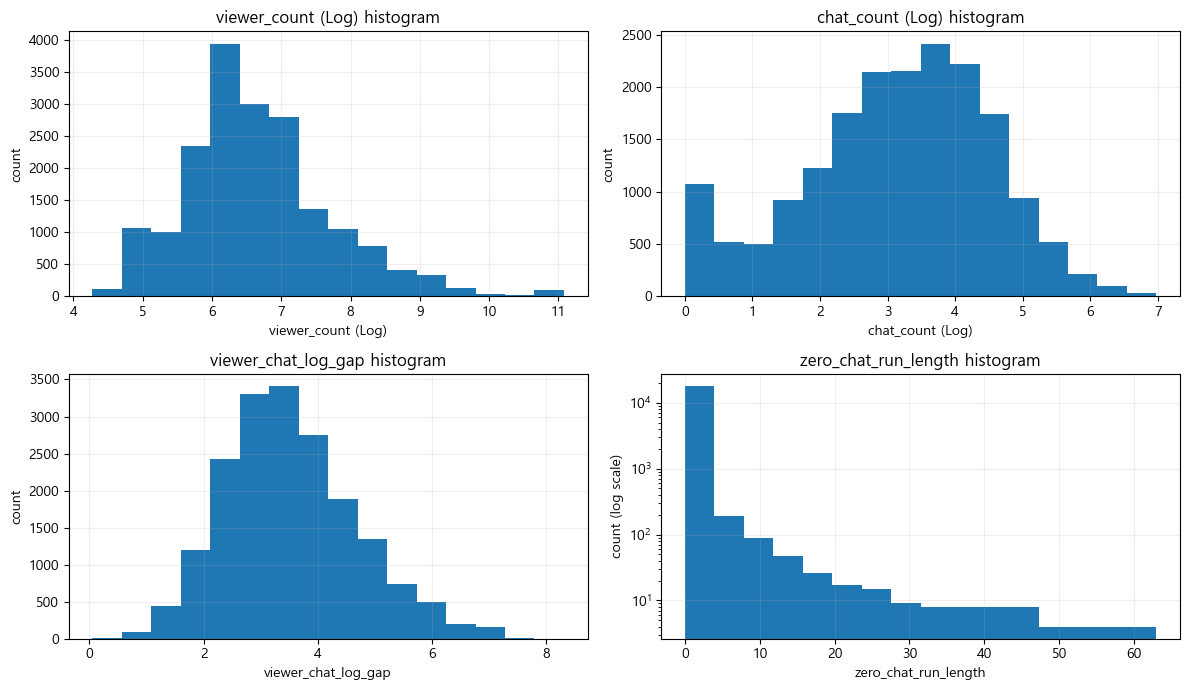

In [15]:
# Slide 2용 핵심 단변량 분포만 출력/저장
slide2_plot_cols = [
    ('viewer_log', 'viewer_count (Log)'),
    ('chat_log', 'chat_count (Log)'),
    ('viewer_chat_log_gap', 'viewer_chat_log_gap'),
    ('zero_chat_run_length', 'zero_chat_run_length')
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for ax, (col, title) in zip(axes, slide2_plot_cols):
    s = plot_df[col].dropna()
    if col == 'zero_chat_run_length':
        ax.hist(s, bins='sturges', log=True)
        ax.set_ylabel('count (log scale)')
    else:
        ax.hist(s, bins='sturges')
        ax.set_ylabel('count')
    ax.set_title(f'{title} histogram')
    ax.set_xlabel(title)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
save_fig(fig, 'slide2_distribution_core.png')
plt.show()


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b>📌 시각화 목적 및 분석 (시간 경과에 따른 세션 지표 변화)</b></span><br>

<br><br><b>[각 그래프의 분석 의도]</b><br>
<b>1. Surviving Sessions: viewer_count_last</b><br>
방송 시간이 경과함에 따라 <b>일반적인 시청자 수의 증감 추세</b>가 어떻게 흘러가는지 파악한다.<br>

<b>2. Surviving Sessions: chat_count</b><br>
방송 시간이 길어질수록 전체적인 <b>채팅 발생량(활성도)</b>이 유지되는지, 혹은 점차 식어가는지 확인한다.<br>

<b>3. Surviving Sessions: unique_chatters</b><br>
시간 흐름에 따라 <b>채팅에 참여하는 고유 시청자 수</b>의 변화를 보며, 시간이 지나도 다양한 사람들이 채팅에 참여하는지 소수만 남는지 파악한다.<br>

<b>4. Surviving Sessions: viewer_chat_log_gap</b><br>
방송 진행 시간에 따른 <b>시청자 규모 대비 채팅 참여 비율(격차)</b>의 흐름을 봅니다. 시간이 지날수록 눈팅 유저가 많아져 격차가 커지는지, 아니면 몰입도가 높아져 간극이 좁혀지는지 분석할 수 있다.
</div>

saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide2_session_trajectory.png


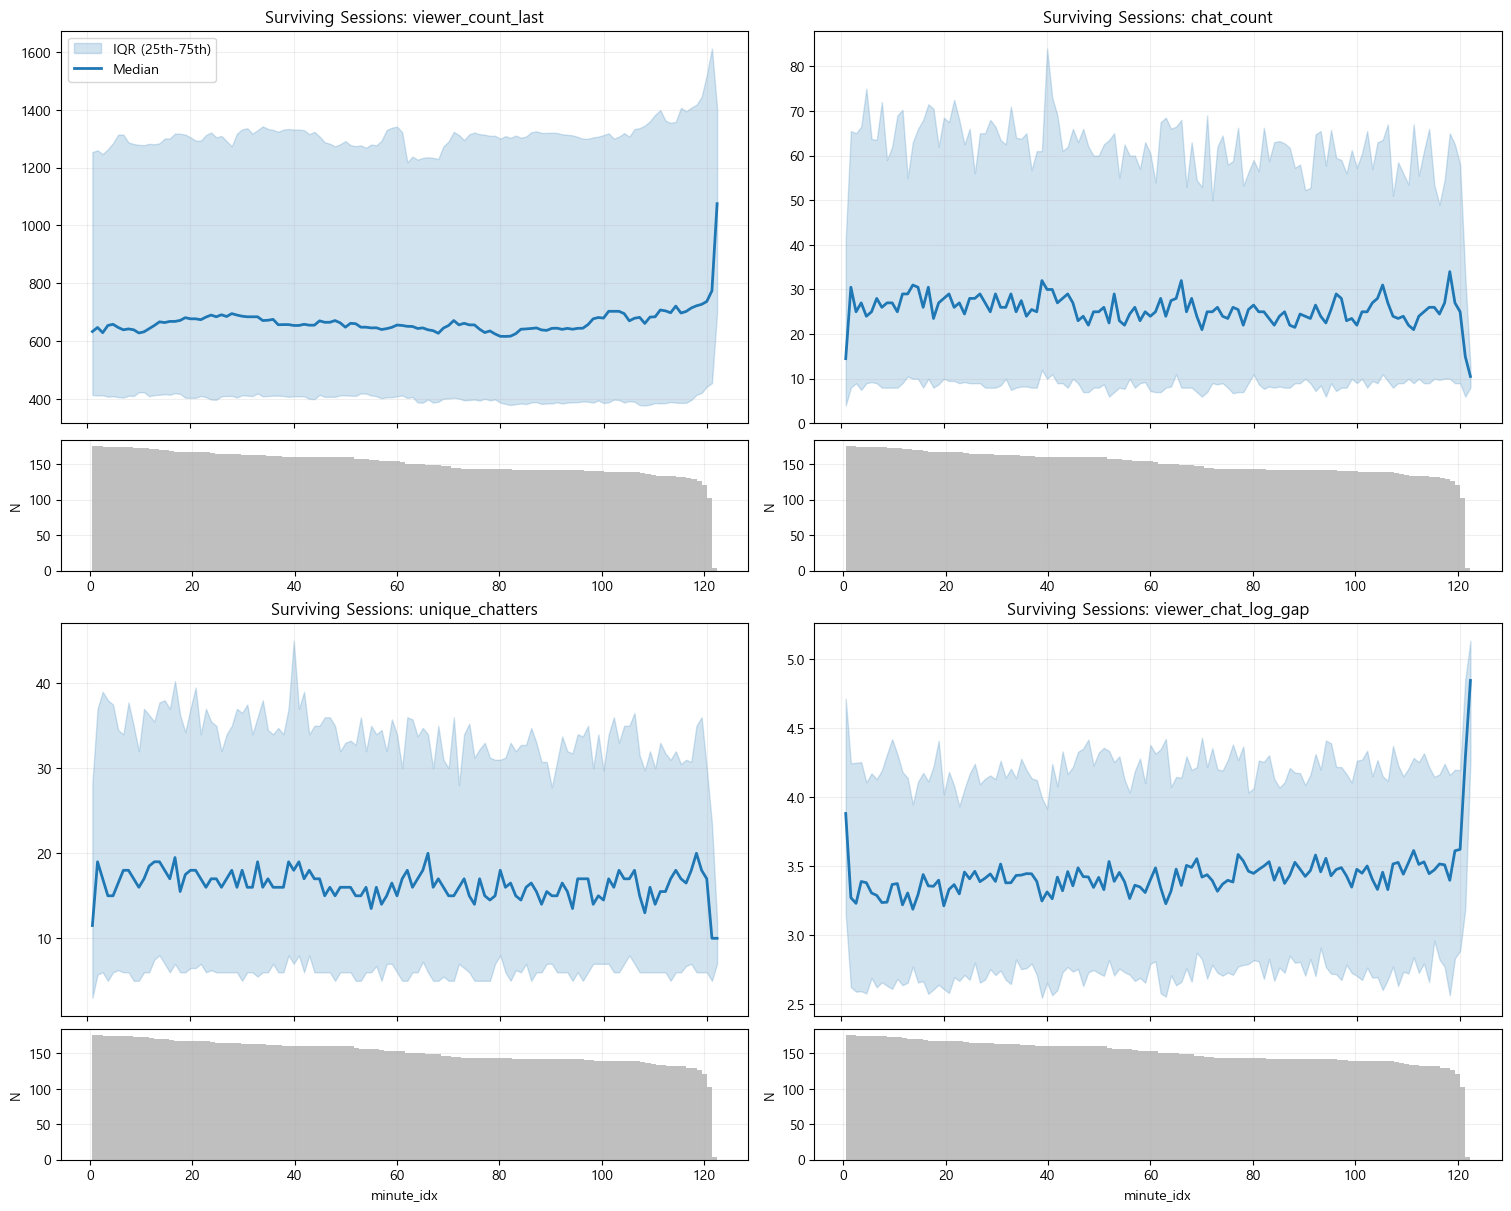

In [16]:
# agg 시 size 대신 session_id의 nunique를 사용하여 완벽한 고유 세션 수 계산
agg = (
    plot_df.groupby('minute_idx')
           .agg(
               median_viewer=('viewer_count_last', 'median'),
               q25_viewer=('viewer_count_last', lambda x: x.quantile(0.25)),
               q75_viewer=('viewer_count_last', lambda x: x.quantile(0.75)),
               
               median_chat=('chat_count', 'median'),
               q25_chat=('chat_count', lambda x: x.quantile(0.25)),
               q75_chat=('chat_count', lambda x: x.quantile(0.75)),
               
               median_unique=('unique_chatters', 'median'),
               q25_unique=('unique_chatters', lambda x: x.quantile(0.25)),
               q75_unique=('unique_chatters', lambda x: x.quantile(0.75)),
               
               median_gap=('viewer_chat_log_gap', 'median'),
               q25_gap=('viewer_chat_log_gap', lambda x: x.quantile(0.25)),
               q75_gap=('viewer_chat_log_gap', lambda x: x.quantile(0.75)),
               
               n_sessions=('session_id', 'nunique') # 핵심 수정 부분
           )
           .reset_index()
)

fig, axes = plt.subplots(
    nrows=4, ncols=2, 
    figsize=(15, 12), 
    gridspec_kw={'height_ratios': [3, 1, 3, 1]},
    constrained_layout=True
)

metrics = [
    ('viewer', 'viewer_count_last'), 
    ('chat', 'chat_count'), 
    ('unique', 'unique_chatters'), 
    ('gap', 'viewer_chat_log_gap')
]

for i, (name, title) in enumerate(metrics):
    col = i % 2
    row_main = (i // 2) * 2
    row_supp = row_main + 1
    
    ax_main = axes[row_main, col]
    ax_supp = axes[row_supp, col]
    
    # 메인 패널
    ax_main.fill_between(
        agg['minute_idx'], agg[f'q25_{name}'], agg[f'q75_{name}'], 
        color='tab:blue', alpha=0.2, label='IQR (25th-75th)'
    )
    ax_main.plot(
        agg['minute_idx'], agg[f'median_{name}'], 
        color='tab:blue', linewidth=2, label='Median'
    )
    ax_main.set_title(f'Surviving Sessions: {title}')
    ax_main.grid(True, alpha=0.2)
    ax_main.tick_params(labelbottom=False)
    if i == 0:
        ax_main.legend(loc='upper left')
        
    # 서포트 패널
    ax_supp.bar(agg['minute_idx'], agg['n_sessions'], color='gray', alpha=0.5, width=1.0)
    ax_supp.set_ylabel('N', fontsize=9)
    ax_supp.grid(True, alpha=0.2)
    
    if row_supp == 3:
        ax_supp.set_xlabel('minute_idx')


save_fig(fig, 'slide2_session_trajectory.png')
plt.show()


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 viewer과 chat 간의 관계 분석</mark></b></span><br><br>

<b>[scatter가 아닌 hexbin을 쓴 이유]</b><br>
데이터가 너무 많아 일반적인 scatter로 분석 시 <b>데이터 밀집도를 제대로 파악하기 어렵기 때문</b>입니다.<br>
Hexbin은 <b>공간을 6각형 여러 개로 분할해 해당 공간의 밀도를 색깔로 나타내주어</b> 직관적인 파악이 가능합니다.<br><br>

<b>[각 그래프의 분석 의도]</b><br>
<b>1. viewer과 chat 간의 관계</b>를 보기 위한 그래프 (log scale 적용)<br>
<b>2. viewer과 unique_chatter 간의 관계</b>를 보는 그래프 (log scale 적용)<br>
<b>3. 1분 단위의 순간적인 변화량 확인:</b> 시청자가 급증/급감할 때 채팅량도 즉각적으로 반응하는지 파악하며, <b>상하위 극단치 1%를 제외한 상황에서의 동기화 패턴</b>을 봅니다.<br>
<b>4. 규모에 따른 격차 확인:</b> 채널의 규모(viewer)가 커질수록 <b>시청자 수와 채팅량 사이의 격차가 어떻게 변하는지</b> 확인합니다.
</div>

saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide3_coupling_core.png


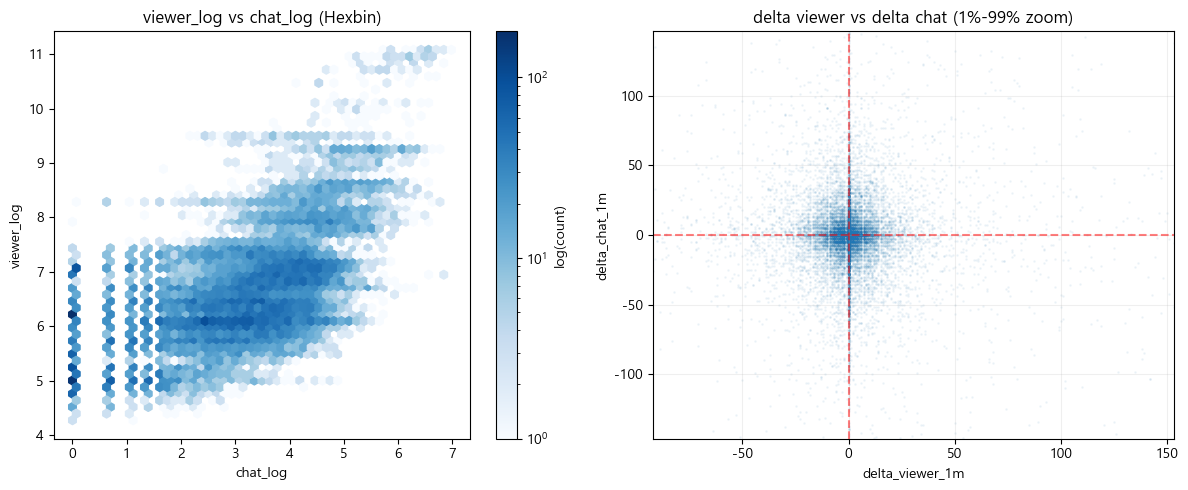

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Slide 3 핵심 패널 1: viewer 규모와 chat 규모의 관계
m = plot_df[['chat_log', 'viewer_log']].dropna()
hb1 = axes[0].hexbin(m['chat_log'], m['viewer_log'], gridsize=50, cmap='Blues', mincnt=1, bins='log')
axes[0].set_title('viewer_log vs chat_log (Hexbin)')
axes[0].set_xlabel('chat_log')
axes[0].set_ylabel('viewer_log')
fig.colorbar(hb1, ax=axes[0], label='log(count)')

# Slide 3 핵심 패널 2: 1분 변화량의 즉시 반응
m = plot_df[['delta_viewer_1m', 'delta_chat_1m']].dropna()
q01_v, q99_v = m['delta_viewer_1m'].quantile([0.01, 0.99])
q01_c, q99_c = m['delta_chat_1m'].quantile([0.01, 0.99])

axes[1].scatter(m['delta_viewer_1m'], m['delta_chat_1m'], s=1, alpha=0.05)
axes[1].axhline(0, linestyle='--', color='red', alpha=0.5)
axes[1].axvline(0, linestyle='--', color='red', alpha=0.5)
axes[1].set_title('delta viewer vs delta chat (1%-99% zoom)')
axes[1].set_xlabel('delta_viewer_1m')
axes[1].set_ylabel('delta_chat_1m')
axes[1].set_xlim(q01_v, q99_v)
axes[1].set_ylim(q01_c, q99_c)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
save_fig(fig, 'slide3_coupling_core.png')
plt.show()


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 EDA 2 - Correlation Summary (설명변수 상관관계 분석)</mark></b></span><br><br>

<b>[코드의 목적 및 시각화 논리]</b><br>
• <b>수업자료 EDA 2에 맞춰 설명변수 간 관계를 표로 정리</b>하는 것이 주 목적.<br>
• 분석에 사용될 8개의 핵심 변수(viewer_log, delta 등)를 묶어 <b>전체 상관계수 행렬(Correlation Matrix)</b>을 1차적으로 계산하여 전체적인 흐름을 파악한다.<br>
• 그 후 방대한 행렬 속에서 직관적인 해석을 돕기 위해, <b>가장 유의미하고 중요한 6개의 변수 쌍(pair)만 따로 추출</b>하여 `corr_focus`라는 요약 데이터프레임으로 정리한다.<br><br>

<b>[Pearson / Spearman 둘 다 확인하는 이유 (교차 검증)]</b><br>
우리의 데이터는 <b>극도로 Skewed(비대칭) 되어 있고 이상치(Outlier)가 존재하는 특성</b>을 가지고 있다. 따라서 단일 지표만 맹신할 수 없으므로, 서로 다른 접근 방식을 가진 두 지표를 비교 분석해야 한다.<br><br>
• <b>Pearson (피어슨 상관계수):</b> 두 변수가 얼마나 일정한 비율로 <b>'선형적(직선) 비례 관계'</b>를 가지는지 측정한다. 수치 자체의 크기를 반영하므로 이상치나 쏠림 현상에 민감하게 반응한다.<br>
• <b>Spearman (스피어만 상관계수):</b> 수치 자체가 아닌 <b>'값들의 순위(Rank)'</b>를 기준으로 <b>'단조적 비례 관계'</b>를 측정한다. 순위 기반이므로 이상치나 극단적인 Skewness에 훨씬 강건(Robust)한 결과를 보여준다.<br>
</div>

In [18]:
# - 수업자료 EDA 2에 맞춰 설명변수 간 관계를 표로 정리

corr_cols = [
    'viewer_log',
    'chat_log',
    'unique_log',
    'delta_viewer_1m',
    'delta_chat_1m',
    'viewer_chat_log_gap',
    'viewer_unique_log_gap',
    'chat_per_viewer_recalc'
]

pearson_corr = plot_df[corr_cols].corr(method='pearson')
spearman_corr = plot_df[corr_cols].corr(method='spearman')

corr_focus = pd.DataFrame({
    'pair': [
        'viewer_log vs chat_log',
        'viewer_log vs unique_log',
        'delta_viewer_1m vs delta_chat_1m',
        'viewer_log vs viewer_chat_log_gap',
        'chat_log vs viewer_chat_log_gap',
        'unique_log vs viewer_unique_log_gap'
    ],
    'pearson': [
        pearson_corr.loc['viewer_log', 'chat_log'],
        pearson_corr.loc['viewer_log', 'unique_log'],
        pearson_corr.loc['delta_viewer_1m', 'delta_chat_1m'],
        pearson_corr.loc['viewer_log', 'viewer_chat_log_gap'],
        pearson_corr.loc['chat_log', 'viewer_chat_log_gap'],
        pearson_corr.loc['unique_log', 'viewer_unique_log_gap']
    ],
    'spearman': [
        spearman_corr.loc['viewer_log', 'chat_log'],
        spearman_corr.loc['viewer_log', 'unique_log'],
        spearman_corr.loc['delta_viewer_1m', 'delta_chat_1m'],
        spearman_corr.loc['viewer_log', 'viewer_chat_log_gap'],
        spearman_corr.loc['chat_log', 'viewer_chat_log_gap'],
        spearman_corr.loc['unique_log', 'viewer_unique_log_gap']
    ]
})

# 발표용 핵심 관계만 저장/출력
slide3_corr_table = corr_focus.iloc[[0, 1, 2, 4]].round(3).reset_index(drop=True)
print('Slide 3 table: viewer-chat coupling correlations')
display(slide3_corr_table)
save_table(slide3_corr_table, 'slide3_corr_table.csv')


Slide 3 table: viewer-chat coupling correlations


,pair,pearson,spearman
0,viewer_log vs chat_log,0.588,0.570
1,viewer_log vs unique_log,0.636,0.618
2,delta_viewer_1m vs delta_chat_1m,-0.024,-0.018
3,chat_log vs viewer_chat_log_gap,-0.683,-0.643


saved table: c:\Users\simon\dm_project_2026\eda_slide_tables\slide3_corr_table.csv


WindowsPath('c:/Users/simon/dm_project_2026/eda_slide_tables/slide3_corr_table.csv')

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Time-lag Response Analysis (viewer 변화 이후 채팅 지연 반응)</mark></b></span><br><br>

<b>[코드의 목적]</b><br>
동일 minute의 <code>delta_viewer_1m</code>와 <code>delta_chat_1m</code> 상관만 보면,
실제 라이브에서 발생할 수 있는 1~몇 분 지연 채팅 반응을 놓칠 수 있다.<br>
따라서 viewer 변화가 발생한 뒤 0~10분 후 chat/unique 변화가 따라오는지 Spearman correlation으로 확인한다.<br><br>

<b>[해석]</b><br>
lag 1~3분에서 correlation이 상승하면 지연 반응 가능성이 있고,
lag 전체가 낮으면 viewer 증가가 chat/unique 반응으로 잘 이어지지 않는 구조로 해석한다.
</div>

,lag_min,viewer_delta_vs_chat_delta_spearman,viewer_delta_vs_unique_delta_spearman,n_chat_pairs,n_unique_pairs
0,0,-0.018,-0.017,18281,18281
1,1,-0.001,0.000,18105,18105
2,2,0.004,0.003,17930,17930
3,3,0.007,0.008,17755,17755
4,4,-0.003,-0.004,17580,17580
5,5,0.006,0.010,17406,17406
6,6,-0.023,-0.020,17232,17232
7,7,0.011,0.014,17058,17058
8,8,-0.001,-0.001,16885,16885
9,9,0.002,0.000,16712,16712


saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide3_lag_response.png
saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\cell_lag_response.png


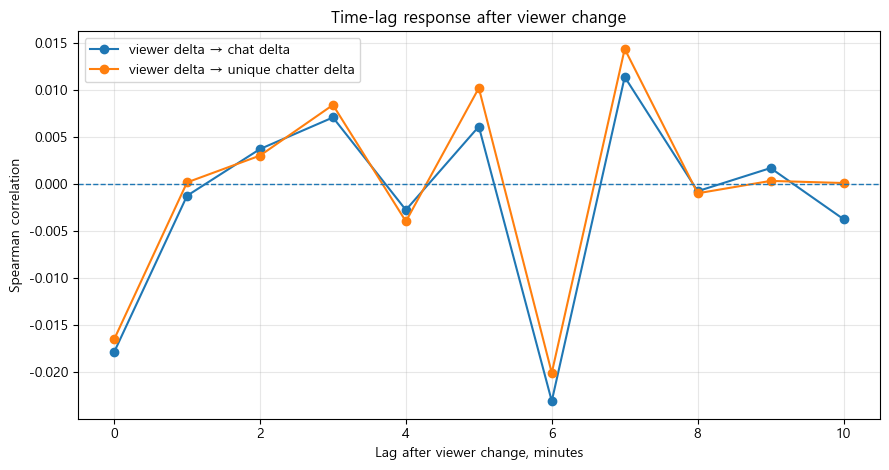

In [19]:
# Time-lag response analysis
# lag k: viewer 변화가 t분에 발생했을 때 chat/unique 변화가 t+k분에 따라오는지 확인

lag_base = plot_df.copy()
lag_base = lag_base.sort_values(SESSION_KEYS + ['minute_ts'])

max_lag = 10
lag_rows = []

for lag in range(max_lag + 1):
    tmp = lag_base.copy()

    tmp[f'delta_chat_tplus_{lag}'] = (
        tmp.groupby(SESSION_KEYS)['delta_chat_1m'].shift(-lag)
    )
    tmp[f'unique_delta_tplus_{lag}'] = (
        tmp.groupby(SESSION_KEYS)['unique_delta_1m'].shift(-lag)
    )

    valid_chat = tmp[['delta_viewer_1m', f'delta_chat_tplus_{lag}']].dropna()
    valid_unique = tmp[['delta_viewer_1m', f'unique_delta_tplus_{lag}']].dropna()

    lag_rows.append({
        'lag_min': lag,
        'viewer_delta_vs_chat_delta_spearman':
            valid_chat['delta_viewer_1m'].corr(
                valid_chat[f'delta_chat_tplus_{lag}'],
                method='spearman'
            ),
        'viewer_delta_vs_unique_delta_spearman':
            valid_unique['delta_viewer_1m'].corr(
                valid_unique[f'unique_delta_tplus_{lag}'],
                method='spearman'
            ),
        'n_chat_pairs': len(valid_chat),
        'n_unique_pairs': len(valid_unique)
    })

lag_corr = pd.DataFrame(lag_rows)
display(lag_corr.round(3))

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.plot(
    lag_corr['lag_min'],
    lag_corr['viewer_delta_vs_chat_delta_spearman'],
    marker='o',
    label='viewer delta → chat delta'
)

ax.plot(
    lag_corr['lag_min'],
    lag_corr['viewer_delta_vs_unique_delta_spearman'],
    marker='o',
    label='viewer delta → unique chatter delta'
)

ax.axhline(0, linestyle='--', linewidth=1)
ax.set_title('Time-lag response after viewer change')
ax.set_xlabel('Lag after viewer change, minutes')
ax.set_ylabel('Spearman correlation')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
save_fig(fig, "slide3_lag_response.png")
save_fig(fig, "cell_lag_response.png")
plt.show()

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 세션 수준 뷰봇 의심군 탐색 Bubble Plot 시각화 논리</mark></b></span><br><br>

<b>[데이터 전처리 및 필터링]</b><br>
• <b>짧은 세션 노이즈 제거:</b> 데이터의 신뢰성을 확보하기 위해, 너무 짧게 진행되어 패턴을 파악하기 힘든 <b>10분 미만의 세션은 제외하고(n >= 10) 분석</b>을 진행한다.<br><br>

<b>[그래프 구성 요소 (4차원 데이터 시각화)]</b><br>
단순한 2차원 산점도를 넘어, <b>위치(X, Y), 크기, 색상</b>을 통해 4가지 지표를 동시에 분석합니다.<br>
• <b>X축 (median_viewer):</b> 세션의 <b>중앙값 시청자 수</b>를 의미하며, 방송 규모의 편차가 크므로 <b>로그 스케일(Log Scale)</b>을 적용해 넓은 범위를 한눈에 본다.<br>
• <b>Y축 (median_gap):</b> <b>시청자 수와 채팅량 간의 중앙값 격차</b>를 나타낸다. 뷰봇이 투입되었다면 시청자는 많으나 채팅이 없어 이 격차가 높게 나타난다.<br>
• <b>버블 크기 :</b> 세션 내에서 발생한 <b>최대 격차(max_gap)</b>를 나타낸다. (시각적 구분을 위해 30을 곱해 스케일링함). 원이 클수록 <b>순간적으로 시청자와 채팅의 괴리가 극심했던 구간</b>이 존재함을 의미함.<br>
• <b>버블 색상 :</b> <b>채팅이 아예 없었던 비율(zero_chat_rate)</b>을 나타낸다. 색상이 밝을수록(노란색에 가까울수록) 0 채팅 비율이 높다는 뜻이다.<br><br>

<b>[시각적 가이드 및 핵심 의심 세션 추출]</b><br>
• <b>저뷰어 주의 구간 분리:</b> X축 <b>100명 선에 시각적 가이드라인</b>을 그었다. 하꼬방(시청자가 적은 방)에서는 뷰봇이 없어도 자연스럽게 채팅이 없을 수 있으므로, <b>의미 있는 분석 구간과 노이즈 구간을 시각적으로 분리</b>하는 역할을 한다.<br>
• <b>Top 5 의심군 텍스트 강조:</b> 시청자 100명 이상인 유의미한 세션 중에서, <b>1) 채팅 없는 비율(zero_chat_rate)이 높고 2) 시청자-채팅 격차(median_gap)가 큰 최상위 5개 세션</b>을 찾아낸다. 이 5개 세션의 <b>`run_id`를 그래프 위에 직접 표기(Annotation)</b>하여 직관적으로 의심군을 특정할 수 있게 설계한다.<br><br>

<b>[데이터 검증]</b><br>
시각화가 끝난 후, <b>최대 격차(max_gap)와 연속 0채팅 최대 길이(max_zero_run)</b>를 기준으로 내림차순 정렬한 상위 10개 데이터를 표(DataFrame)로 출력하여 <b>실제 수치를 기반으로 한 번 더 크로스 체크</b>를 진행한다.
</div>

saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\backup_session_bubble_visual_guide.png


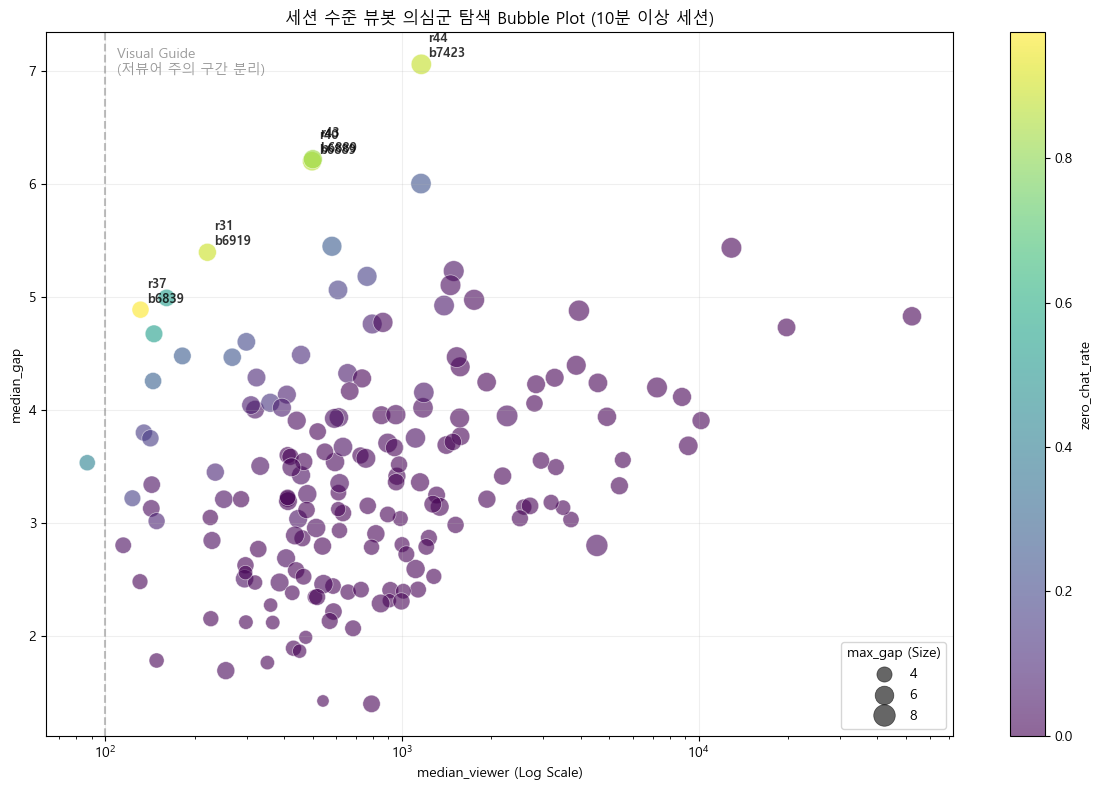

,run_id,broad_no,user_id,n,start_ts,end_ts,median_viewer,max_viewer,mean_chat,mean_unique,zero_chat_rate,max_zero_run,median_gap,max_gap
114,42,18411997,b044e3a3b9259246bc92e863e7d3f3b8,61,2026-04-17 23:00:00,2026-04-18 00:00:00,4541.000,5055.000,325.033,125.590,0.016,1,2.802,8.316
77,38,18397345,0b33823ac81de48d5b78a38cdbc0ab94,60,2026-04-16 21:01:00,2026-04-16 22:00:00,2262.000,3411.000,48.267,26.217,0.017,1,3.947,7.949
76,38,18394862,2086f44c7b09a17cef6786f21389db3b,121,2026-04-16 20:00:00,2026-04-16 22:00:00,3951.000,4173.000,38.107,26.967,0.000,0,4.877,7.613
175,48,18453929,aed9d6557bebfb21ab3d081b862cdd2d,120,2026-04-19 23:00:00,2026-04-20 00:59:00,1751.000,2086.000,14.975,11.717,0.008,1,4.973,7.466
93,40,18407163,aed9d6557bebfb21ab3d081b862cdd2d,121,2026-04-17 17:00:00,2026-04-17 19:00:00,1495.000,1815.000,12.950,8.620,0.033,1,5.228,7.382
107,42,18407163,aed9d6557bebfb21ab3d081b862cdd2d,120,2026-04-17 23:00:00,2026-04-18 00:59:00,1530.500,1710.000,19.108,12.175,0.008,1,4.466,7.326
151,46,18444666,d2fb83a5db130bf4d273c981b82ca41f,121,2026-04-19 17:00:00,2026-04-19 19:00:00,1458.000,1595.000,9.264,6.496,0.017,1,5.103,7.309
109,42,18408496,26ae7850ad5b6b09ca864d482dc7fa50,121,2026-04-17 23:00:00,2026-04-18 01:00:00,7241.000,8179.000,116.405,76.950,0.000,0,4.198,7.293
26,33,18360506,7ce8032370ac5121dcabce7bad375ced,120,2026-04-14 23:00:00,2026-04-15 00:59:00,12898.500,13291.000,81.042,54.808,0.000,0,5.433,7.278
79,39,18391303,c100f81959d1c17044be0541eed56f5b,19,2026-04-16 23:00:00,2026-04-16 23:18:00,1387.000,1430.000,14.842,11.263,0.053,1,4.923,7.199


In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

# 짧은 세션 노이즈 제거 (10분 이상 세션만)
plot_data = session_summary[session_summary['n'] >= 10].copy()

# 버블 크기 스케일링
bubble_size = plot_data['max_gap'].fillna(0) * 30 

sc = ax.scatter(
    plot_data['median_viewer'],
    plot_data['median_gap'],
    s=bubble_size,
    c=plot_data['zero_chat_rate'].fillna(0),
    cmap='viridis',
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

ax.set_title('세션 수준 뷰봇 의심군 탐색 Bubble Plot (10분 이상 세션)')
ax.set_xlabel('median_viewer (Log Scale)') 
ax.set_ylabel('median_gap')
ax.set_xscale('log') 

# 시각적 가이드라인 (Threshold 아님)
ax.axvline(100, color='gray', linestyle='--', alpha=0.5)
ax.text(110, ax.get_ylim()[1]*0.95, 'Visual Guide\n(저뷰어 주의 구간 분리)', color='gray', alpha=0.8)
ax.grid(True, alpha=0.2)

# 색상 범례 (zero_chat_rate)
cbar = plt.colorbar(sc, ax=ax, label='zero_chat_rate')


# 상위 의심 세션 Annotation
# 기준: 시청자 100명 이상 중 zero_chat_rate 최상위, 그 다음 median_gap 최상위 5개 추출

suspects = plot_data[plot_data['median_viewer'] >= 100].sort_values(
    ['zero_chat_rate', 'median_gap'], ascending=[False, False]
).head(5)

for _, row in suspects.iterrows():
    ax.annotate(
        f"r{row['run_id']}\nb{str(row['broad_no'])[-4:]}",
        (row['median_viewer'], row['median_gap']),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=9,
        fontweight='bold', 
        color='black',
        alpha=0.8
    )


#  버블 크기(max_gap) 범례
# 면적(s)으로 들어간 값을 다시 30으로 나누어 원래의 max_gap 수치로 복원하여 표시
handles, labels = sc.legend_elements(prop="sizes", alpha=0.6, num=4, func=lambda s: np.round(s / 30, 1))
ax.legend(handles, labels, loc="lower right", title="max_gap (Size)")

plt.tight_layout()
save_fig(fig, 'backup_session_bubble_visual_guide.png')
plt.show()

display(plot_data.sort_values(['max_gap', 'max_zero_run'], ascending=False).head(10))

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Session Type Clustering (방송 세션 행동 유형 분류)</mark></b></span><br><br>

<b>[핵심 목적]</b><br>
이 섹션은 <b>의심 세션을 확정하는 모델</b>이 아니라, 10분 이상 관측된 broadcast session을
<b>viewer-chat 행동 유형</b>으로 나누는 EDA이다.<br>
따라서 오른쪽 슬라이드에서는 “뷰봇 판정”이 아니라 <b>normal/active vs sparse/silent 같은 session type profile</b>을 보여준다.<br><br>

<b>[분석 단위]</b><br>
• clustering 단위는 minute row가 아니라 <b>broadcast session = run_id + broad_no</b>이다.<br>
• 각 session 내부의 1분 row를 먼저 요약한 뒤, 그 session-level feature로 clustering한다.<br><br>

<b>[Feature 선정 원칙]</b><br>
• session의 전반적 행동 유형을 설명하는 변수만 사용한다.<br>
• rule candidate나 IsolationForest score처럼 후보 선별 결과는 clustering feature로 넣지 않는다.<br>
• <code>max_gap</code>처럼 순간 극단값은 review candidate 쪽 변수로 보고, 유형 분류에는 포함하지 않는다.<br><br>

<b>[방법론]</b><br>
• Count형 변수는 skew가 크므로 <code>log1p</code>로 변환한다.<br>
• feature scale 차이와 outlier 영향을 줄이기 위해 <b>RobustScaler</b>를 사용한다.<br>
• 군집 수는 임의로 정하지 않고, <b>KMeans silhouette score</b>가 가장 높은 k를 선택한다.<br>
</div>


KMeans best k by silhouette: 2


,k,silhouette,inertia
0,2,0.887,2655.424
1,3,0.790,1201.721
2,4,0.761,657.916
3,5,0.453,476.128
4,6,0.365,369.218


,session_type_cluster,n_sessions,median_viewer,mean_chat_per_min,mean_unique_per_min,zero_chat_rate,median_gap,max_zero_run,session_type
0,1,8,191.000,0.838,0.542,0.742,5.192,17.000,sparse/silent
1,0,165,658.500,53.996,28.821,0.024,3.269,0.000,normal/active


saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide4_session_type_selection.png


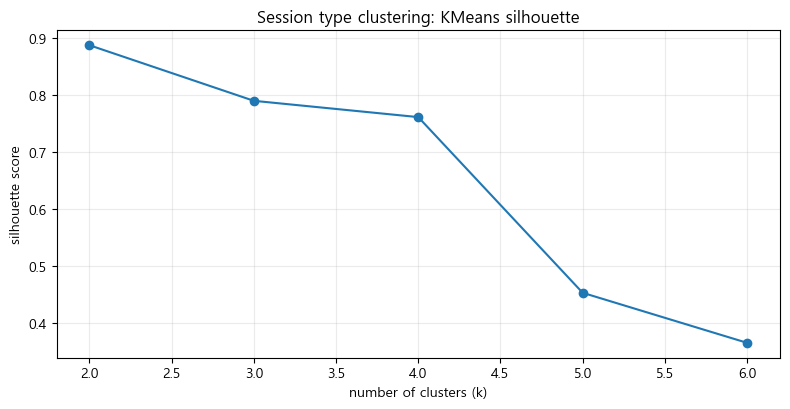

saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide4_session_type_map.png


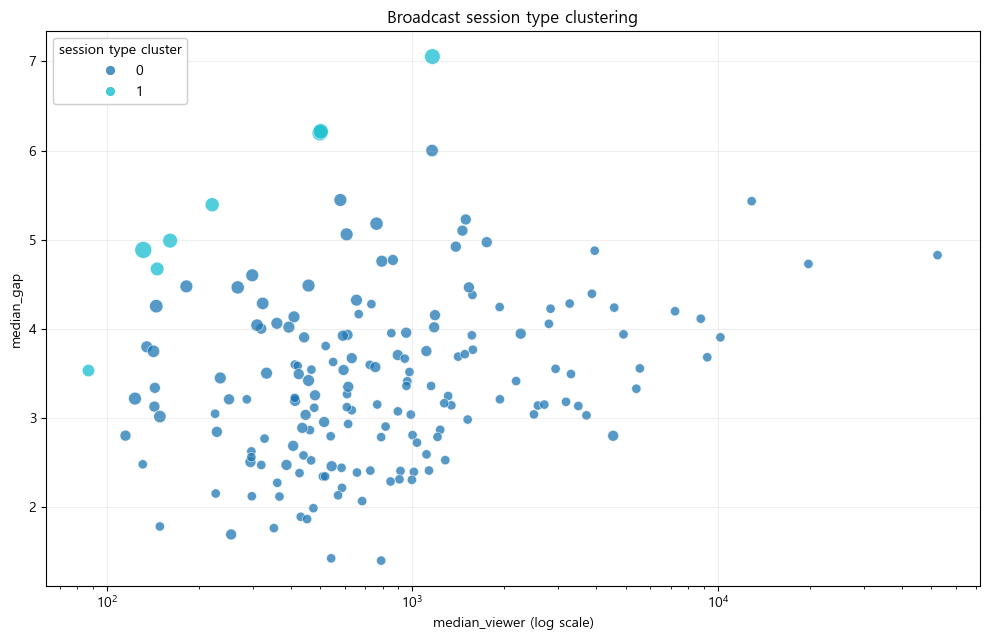

saved table: c:\Users\simon\dm_project_2026\eda_slide_tables\slide4_cluster_selection_table.csv
saved table: c:\Users\simon\dm_project_2026\eda_slide_tables\slide4_session_type_profile_table.csv


WindowsPath('c:/Users/simon/dm_project_2026/eda_slide_tables/slide4_session_type_profile_table.csv')

In [21]:
# Slide 4 오른쪽: 방송 세션 행동 유형 clustering
# 목적: "의심 세션 판정"이 아니라 10분 이상 broadcast session의 viewer-chat 행동 유형을 분류한다.
# 단위: broadcast session = run_id + broad_no
# 중요: rule_score, iforest_score, candidate_minute 같은 후속 후보선정 결과는 clustering feature로 사용하지 않는다.

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) clustering 대상: 10분 이상 broadcast session
cluster_data = session_summary_10m.copy()

# 2) session-level clustering features
# count형 변수는 skew가 크므로 log1p 변환한다.
cluster_data['log_median_viewer'] = np.log1p(cluster_data['median_viewer'])
cluster_data['log_mean_chat'] = np.log1p(cluster_data['mean_chat'])
cluster_data['log_mean_unique'] = np.log1p(cluster_data['mean_unique'])
cluster_data['log_max_zero_run'] = np.log1p(cluster_data['max_zero_run'])

cluster_features = [
    'log_median_viewer',   # 방송 규모
    'log_mean_chat',       # 평균 채팅량
    'log_mean_unique',     # 평균 고유 채팅자 수
    'zero_chat_rate',      # 0-chat minute 비율
    'median_gap',          # viewer-chat log gap의 session 중앙값
    'log_max_zero_run'     # 연속 0-chat 지속성
]

X = cluster_data[cluster_features].replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 3) k 선택: 임의 기준 없이 silhouette score로 비교
# n_sessions가 충분할 때 2~6개까지 비교한다.
k_values = list(range(2, min(7, len(cluster_data))))

cluster_selection_rows = []
labels_by_k = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)
    labels_by_k[k] = labels

    cluster_selection_rows.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'inertia': km.inertia_
    })

cluster_selection_table = (
    pd.DataFrame(cluster_selection_rows)
      .sort_values('k')
      .reset_index(drop=True)
)

best_k = int(cluster_selection_table.sort_values('silhouette', ascending=False).iloc[0]['k'])

# 4) 최종 KMeans
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=50)
cluster_data['session_type_cluster'] = final_km.fit_predict(X_scaled)

# 기존 downstream 코드 호환을 위해 kmeans_cluster도 동일하게 둔다.
cluster_data['kmeans_cluster'] = cluster_data['session_type_cluster']

# 5) cluster profile
session_type_profile_table = (
    cluster_data.groupby('session_type_cluster')
                .agg(
                    n_sessions=('run_id', 'size'),
                    median_viewer=('median_viewer', 'median'),
                    mean_chat_per_min=('mean_chat', 'mean'),
                    mean_unique_per_min=('mean_unique', 'mean'),
                    zero_chat_rate=('zero_chat_rate', 'mean'),
                    median_gap=('median_gap', 'median'),
                    max_zero_run=('max_zero_run', 'median')
                )
                .reset_index()
                .sort_values(['zero_chat_rate', 'mean_chat_per_min'], ascending=[False, True])
                .reset_index(drop=True)
)

# 6) 해석용 label: clustering 기준이 아니라 profile 해석용 이름이다.
# best_k=2일 때, zero_chat_rate가 높고 mean_chat이 낮은 cluster를 sparse/silent로 해석한다.
if best_k == 2:
    sparse_cluster_id = session_type_profile_table.iloc[0]['session_type_cluster']
    session_type_profile_table['session_type'] = np.where(
        session_type_profile_table['session_type_cluster'].eq(sparse_cluster_id),
        'sparse/silent',
        'normal/active'
    )
else:
    # k가 2가 아니면 임의 threshold 없이 numeric type label만 붙이고,
    # profile table에서 수치를 보고 해석한다.
    session_type_profile_table['session_type'] = (
        'type_' + session_type_profile_table['session_type_cluster'].astype(str)
    )

cluster_data = cluster_data.merge(
    session_type_profile_table[['session_type_cluster', 'session_type']],
    on='session_type_cluster',
    how='left'
)

# 기존 표 이름 호환
kmeans_profile = session_type_profile_table.rename(columns={'session_type_cluster': 'kmeans_cluster'}).copy()
gmm_profile = pd.DataFrame()  # GMM은 메인 슬라이드에서 사용하지 않음. 혼동 방지를 위해 빈 표로 둔다.

print('KMeans best k by silhouette:', best_k)
display(cluster_selection_table.round(3))
display(session_type_profile_table.round(3))

# 7) 발표용 그림: k 선택 근거
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(cluster_selection_table['k'], cluster_selection_table['silhouette'], marker='o')
ax.set_title('Session type clustering: KMeans silhouette')
ax.set_xlabel('number of clusters (k)')
ax.set_ylabel('silhouette score')
ax.grid(True, alpha=0.25)
plt.tight_layout()
save_fig(fig, 'slide4_session_type_selection.png')
plt.show()

# 8) 발표용 그림: 같은 bubble 좌표에서 session type 색상 표시
fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = ax.scatter(
    cluster_data['median_viewer'],
    cluster_data['median_gap'],
    s=45 + 25 * np.log1p(cluster_data['max_zero_run'].fillna(0)),
    c=cluster_data['session_type_cluster'],
    cmap='tab10',
    alpha=0.75,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xscale('log')
ax.set_xlabel('median_viewer (log scale)')
ax.set_ylabel('median_gap')
ax.set_title('Broadcast session type clustering')
ax.grid(True, alpha=0.2)

legend1 = ax.legend(*scatter.legend_elements(), title='session type cluster', loc='upper left')
ax.add_artist(legend1)

plt.tight_layout()
save_fig(fig, 'slide4_session_type_map.png')
plt.show()

# 9) 이후 섹터에서 쓰기 쉽게 session_summary_10m에 cluster label을 붙인다.
session_summary_10m = cluster_data.copy()

# 발표용 표 저장
slide4_cluster_selection_table = cluster_selection_table.round(3).reset_index(drop=True)
slide4_session_type_profile_table = session_type_profile_table.round(3).reset_index(drop=True)

save_table(slide4_cluster_selection_table, 'slide4_cluster_selection_table.csv')
save_table(slide4_session_type_profile_table, 'slide4_session_type_profile_table.csv')


In [ ]:
# Slide 4 추가 비교: Gaussian Mixture Model(GMM) clustering
# 기준: GMM은 likelihood 기반 모델이므로 BIC가 가장 작은 component 수를 선택한다.

from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

new_cluster_data = session_summary_10m.copy()
gmm_component_values = list(range(2, min(7, len(new_cluster_data))))


gmm_selection_rows = []
gmm_models_by_k = {}
gmm_labels_by_k = {}

for n_components in gmm_component_values:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=42,
        n_init=20,
        reg_covar=1e-6
    )
    labels = gmm.fit_predict(X_scaled)

    gmm_models_by_k[n_components] = gmm
    gmm_labels_by_k[n_components] = labels

    n_labels = len(np.unique(labels))
    sil = np.nan
    if 2 <= n_labels <= len(cluster_data) - 1:
        sil = silhouette_score(X_scaled, labels)

    gmm_selection_rows.append({
        "n_components": n_components,
        "bic": gmm.bic(X_scaled),
        "aic": gmm.aic(X_scaled),
        "silhouette": sil
    })

gmm_selection_table = (
    pd.DataFrame(gmm_selection_rows)
        .sort_values("n_components")
        .reset_index(drop=True)
)

best_gmm_components = int(
    gmm_selection_table.sort_values(["bic", "n_components"], ascending=[True, True])
                        .iloc[0]["n_components"]
)

final_gmm = gmm_models_by_k[best_gmm_components]
new_cluster_data["gmm_cluster"] = gmm_labels_by_k[best_gmm_components]
new_cluster_data["gmm_cluster_confidence"] = final_gmm.predict_proba(X_scaled).max(axis=1)

gmm_profile = (
    new_cluster_data.groupby("gmm_cluster")
                .agg(
                    n_sessions=("run_id", "size"),
                    median_viewer=("median_viewer", "median"),
                    mean_chat_per_min=("mean_chat", "mean"),
                    mean_unique_per_min=("mean_unique", "mean"),
                    zero_chat_rate=("zero_chat_rate", "mean"),
                    median_gap=("median_gap", "median"),
                    max_zero_run=("max_zero_run", "median"),
                    mean_gmm_confidence=("gmm_cluster_confidence", "mean")
                )
                .reset_index()
                .sort_values(["zero_chat_rate", "mean_chat_per_min"], ascending=[False, True])
                .reset_index(drop=True)
)

print("GMM best n_components by BIC:", best_gmm_components)
display(gmm_selection_table.round(3))
display(gmm_profile.round(3))

# BIC/AIC는 GMM의 component 수 선택 근거이다. 낮을수록 좋다.
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(gmm_selection_table["n_components"], gmm_selection_table["bic"], marker="o", label="BIC")
ax.plot(gmm_selection_table["n_components"], gmm_selection_table["aic"], marker="o", label="AIC")
ax.set_title("GMM component selection")
ax.set_xlabel("number of components")
ax.set_ylabel("information criterion (lower is better)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
save_fig(fig, "slide4_gmm_component_selection.png")
plt.show()

# KMeans와 같은 bubble 좌표에서 GMM cluster를 확인한다.
fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = ax.scatter(
    new_cluster_data["median_viewer"],
    new_cluster_data["median_gap"],
    s=45 + 25 * np.log1p(new_cluster_data["max_zero_run"].fillna(0)),
    c=new_cluster_data["gmm_cluster"],
    cmap="tab10",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5
)

ax.set_xscale("log")
ax.set_xlabel("median_viewer (log scale)")
ax.set_ylabel("median_gap")
ax.set_title("Broadcast session type clustering: GMM")
ax.grid(True, alpha=0.2)

legend1 = ax.legend(*scatter.legend_elements(), title="GMM cluster", loc="upper left")
ax.add_artist(legend1)

plt.tight_layout()
save_fig(fig, "slide4_gmm_session_type_map.png")
plt.show()

# 이후 저장/모델 handoff에서 GMM label도 함께 남도록 session_summary_10m을 갱신한다.
session_summary_10m = new_cluster_data.copy()

slide4_gmm_selection_table = gmm_selection_table.round(3).reset_index(drop=True)
slide4_gmm_profile_table = gmm_profile.round(3).reset_index(drop=True)

save_table(slide4_gmm_selection_table, "slide4_gmm_selection_table.csv")
save_table(slide4_gmm_profile_table, "slide4_gmm_profile_table.csv")


In [2]:
# Slide 4 추가 비교: HDBSCAN clustering

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
plt.rcParams['axes.unicode_minus'] = False
# sklearn 버전에 따라 HDBSCAN이 없을 수 있으므로 fallback 처리
try:
    from sklearn.cluster import HDBSCAN
    HDBSCAN_BACKEND = "sklearn"
except ImportError:
    try:
        import hdbscan
        HDBSCAN = hdbscan.HDBSCAN
        HDBSCAN_BACKEND = "hdbscan_package"
    except ImportError as e:
        raise ImportError(
            "HDBSCAN을 사용하려면 scikit-learn 최신 버전 또는 hdbscan 패키지가 필요합니다.\n"
            "설치 예시: pip install hdbscan"
        ) from e


# GMM 이후의 session_summary_10m을 새롭게 복제한다.
# 기존 KMeans/GMM 결과를 덮어쓰지 않고 HDBSCAN 전용 결과만 추가한다.
hdbscan_data = session_summary_10m.copy()

n_sessions = len(hdbscan_data)

# HDBSCAN은 cluster 개수 k를 직접 정하지 않는다.
# 대신 min_cluster_size를 바꿔가며 안정적인 밀도 cluster가 어떻게 나오는지 비교한다.
candidate_min_cluster_sizes = sorted(set([
    5,
    max(5, int(0.03 * n_sessions)),
    max(5, int(0.05 * n_sessions)),
    max(5, int(0.08 * n_sessions)),
    max(5, int(0.10 * n_sessions)),
]))

candidate_min_cluster_sizes = [
    v for v in candidate_min_cluster_sizes
    if 2 <= v < n_sessions
]

hdbscan_selection_rows = []
hdbscan_models = {}
hdbscan_labels = {}

for min_cluster_size in candidate_min_cluster_sizes:
    # min_samples를 min_cluster_size의 절반 정도로 두면
    # 너무 공격적으로 noise를 만들지 않으면서도 안정적인 cluster를 찾는 쪽으로 작동한다.
    min_samples = max(2, min_cluster_size // 2)

    if HDBSCAN_BACKEND == "sklearn":
        model = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom"
        )
    else:
        model = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True
        )

    labels = model.fit_predict(X_scaled)

    hdbscan_models[min_cluster_size] = model
    hdbscan_labels[min_cluster_size] = labels

    non_noise_mask = labels != -1
    n_noise = int((labels == -1).sum())
    noise_ratio = n_noise / len(labels)

    cluster_ids = sorted([c for c in np.unique(labels) if c != -1])
    n_clusters = len(cluster_ids)

    # silhouette은 noise(-1)를 제외한 안정 cluster에 대해서만 계산한다.
    sil = np.nan
    if n_clusters >= 2 and non_noise_mask.sum() > n_clusters:
        sil = silhouette_score(X_scaled[non_noise_mask], labels[non_noise_mask])

    # coverage를 함께 반영한다.
    # silhouette만 높고 대부분을 noise로 버리는 해를 방지하기 위한 보조 점수이다.
    coverage = 1 - noise_ratio
    balanced_score = sil * coverage if not np.isnan(sil) else np.nan

    hdbscan_selection_rows.append({
        "min_cluster_size": min_cluster_size,
        "min_samples": min_samples,
        "n_clusters_excluding_noise": n_clusters,
        "n_noise_sessions": n_noise,
        "noise_ratio": noise_ratio,
        "coverage": coverage,
        "silhouette_non_noise": sil,
        "balanced_score": balanced_score
    })

hdbscan_selection_table = (
    pd.DataFrame(hdbscan_selection_rows)
      .sort_values("min_cluster_size")
      .reset_index(drop=True)
)

# 최종 선택:
# stable cluster가 2개 이상 나오고, silhouette과 coverage가 동시에 좋은 설정을 선택한다.
valid_hdbscan_selection = hdbscan_selection_table.dropna(subset=["balanced_score"]).copy()
valid_hdbscan_selection = valid_hdbscan_selection[
    valid_hdbscan_selection["n_clusters_excluding_noise"] >= 2
]

if len(valid_hdbscan_selection) == 0:
    # 유효한 cluster가 안 나오면 noise_ratio가 가장 낮은 설정을 fallback으로 사용
    best_hdbscan_row = (
        hdbscan_selection_table
        .sort_values(["noise_ratio", "min_cluster_size"], ascending=[True, True])
        .iloc[0]
    )
else:
    best_hdbscan_row = (
        valid_hdbscan_selection
        .sort_values(["balanced_score", "silhouette_non_noise", "coverage"],
                     ascending=[False, False, False])
        .iloc[0]
    )

best_min_cluster_size = int(best_hdbscan_row["min_cluster_size"])
final_hdbscan = hdbscan_models[best_min_cluster_size]
final_hdbscan_labels = hdbscan_labels[best_min_cluster_size]

hdbscan_data["hdbscan_cluster"] = final_hdbscan_labels
hdbscan_data["hdbscan_is_noise"] = hdbscan_data["hdbscan_cluster"].eq(-1).astype(int)

# membership confidence / outlier score는 backend별로 존재 여부가 다를 수 있음
if hasattr(final_hdbscan, "probabilities_"):
    hdbscan_data["hdbscan_membership_strength"] = final_hdbscan.probabilities_
else:
    hdbscan_data["hdbscan_membership_strength"] = np.where(
        hdbscan_data["hdbscan_cluster"].eq(-1),
        0.0,
        1.0
    )

if hasattr(final_hdbscan, "outlier_scores_"):
    hdbscan_data["hdbscan_outlier_score"] = final_hdbscan.outlier_scores_
else:
    hdbscan_data["hdbscan_outlier_score"] = np.nan


hdbscan_profile = (
    hdbscan_data.groupby("hdbscan_cluster")
        .agg(
            n_sessions=("run_id", "size"),
            median_viewer=("median_viewer", "median"),
            mean_chat_per_min=("mean_chat", "mean"),
            mean_unique_per_min=("mean_unique", "mean"),
            zero_chat_rate=("zero_chat_rate", "mean"),
            median_gap=("median_gap", "median"),
            max_zero_run=("max_zero_run", "median"),
            mean_membership_strength=("hdbscan_membership_strength", "mean"),
            mean_outlier_score=("hdbscan_outlier_score", "mean")
        )
        .reset_index()
        .sort_values(["hdbscan_cluster"])
        .reset_index(drop=True)
)

print("HDBSCAN backend:", HDBSCAN_BACKEND)
print("Selected min_cluster_size:", best_min_cluster_size)
print("Selected min_samples:", int(best_hdbscan_row["min_samples"]))
print("Number of clusters excluding noise:", int(best_hdbscan_row["n_clusters_excluding_noise"]))
print("Noise ratio:", round(float(best_hdbscan_row["noise_ratio"]), 3))

display(hdbscan_selection_table.round(3))
display(hdbscan_profile.round(3))


# HDBSCAN parameter selection table 저장
slide4_hdbscan_selection_table = hdbscan_selection_table.round(3).reset_index(drop=True)
slide4_hdbscan_profile_table = hdbscan_profile.round(3).reset_index(drop=True)

save_table(slide4_hdbscan_selection_table, "slide4_hdbscan_selection_table.csv")
save_table(slide4_hdbscan_profile_table, "slide4_hdbscan_profile_table.csv")


# HDBSCAN parameter selection 시각화
fig, ax1 = plt.subplots(figsize=(8, 4.2))

ax1.plot(
    hdbscan_selection_table["min_cluster_size"],
    hdbscan_selection_table["silhouette_non_noise"],
    marker="o",
    label="silhouette excluding noise"
)
ax1.plot(
    hdbscan_selection_table["min_cluster_size"],
    hdbscan_selection_table["balanced_score"],
    marker="o",
    label="balanced score"
)
ax1.set_xlabel("min_cluster_size")
ax1.set_ylabel("score")
ax1.set_title("HDBSCAN parameter selection")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(
    hdbscan_selection_table["min_cluster_size"],
    hdbscan_selection_table["noise_ratio"],
    marker="s",
    linestyle="--",
    label="noise ratio"
)
ax2.set_ylabel("noise ratio")
ax2.legend(loc="upper right")

plt.tight_layout()
save_fig(fig, "slide4_hdbscan_parameter_selection.png")
plt.show()


# KMeans/GMM과 같은 bubble 좌표에서 HDBSCAN cluster를 확인한다.
fig, ax = plt.subplots(figsize=(10, 6.5))

scatter = ax.scatter(
    hdbscan_data["median_viewer"],
    hdbscan_data["median_gap"],
    s=45 + 25 * np.log1p(hdbscan_data["max_zero_run"].fillna(0)),
    c=hdbscan_data["hdbscan_cluster"],
    cmap="tab10",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.5
)

ax.set_xscale("log")
ax.set_xlabel("median_viewer (log scale)")
ax.set_ylabel("median_gap")
ax.set_title("Broadcast session type clustering: HDBSCAN")
ax.grid(True, alpha=0.2)

legend1 = ax.legend(
    *scatter.legend_elements(),
    title="HDBSCAN cluster\n-1 = noise",
    loc="upper left"
)
ax.add_artist(legend1)

plt.tight_layout()
save_fig(fig, "slide4_hdbscan_session_type_map.png")
plt.show()


# 이후 분석에서 필요하면 이 데이터프레임을 사용하면 됨.
# 기존 session_summary_10m은 덮어쓰지 않는다.
slide4_hdbscan_data = hdbscan_data.copy()

NameError: name 'session_summary_10m' is not defined

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 Session-level IsolationForest Review Flag</mark></b></span><br><br>

<b>[목적]</b><br>
IsolationForest는 10분 이상 broadcast session을 <b>session-level feature 공간에서 고립된 정도</b>로 flagging하기 위한 비지도 screening이다. 이 결과는 최종 anomaly 판정이나 뷰봇 확률이 아니라, <b>review map에서 우선적으로 살펴볼 세션을 표시하는 보조 신호</b>이다.<br><br>

<b>[판정 기준]</b><br>
별도의 사용자 정의 threshold를 두지 않는다. <code>IsolationForest(contamination='auto')</code>의 <code>predict()</code> 결과를 그대로 사용한다. scikit-learn의 <code>decision_function</code>은 0을 기준으로 하며, <code>decision_function &lt; 0</code>인 세션이 <code>-1</code>로 flag된다. 따라서 그래프의 0선은 임의로 만든 기준선이 아니라 모델 API의 decision cutoff이다.<br><br>

<b>[사용 feature]</b><br>
단위는 minute row가 아니라 <b>broadcast session = run_id + broad_no</b>이다. 사용 feature는 <code>log_median_viewer</code>, <code>zero_chat_rate</code>, <code>median_gap</code>, <code>max_gap</code>, <code>log_mean_unique</code>, <code>log_max_zero_run</code>이다. count 계열은 <code>log1p</code>로 변환하고 <code>RobustScaler</code>로 scale을 맞춘다.<br><br>

<b>[시각화 해석]</b><br>
Bubble plot의 빨간 테두리는 <code>iforest_label == -1</code>인 세션이다. 색은 <code>zero_chat_rate</code>, 점 크기는 <code>max_gap</code>을 뜻한다. 특정 상위 N개를 임의로 골라 라벨링하지 않는다.
</div>


IsolationForest flagged session count: 25


,criterion,decision_score_cutoff,flag_condition,flagged_label,n_flagged_sessions,n_total_sessions
0,sklearn IsolationForest predict,0.000,decision_function < 0,-1,25,173


,feature,meaning
0,log_median_viewer,session 내부 viewer_count_last 중앙값의 log1p
1,zero_chat_rate,session 내부 chat_count=0 minute 비율
2,median_gap,session 내부 log1p(viewer)-log1p(chat) 중앙값
3,max_gap,session 내부 최대 viewer-chat log gap
4,log_mean_unique,session 내부 평균 unique_chatters의 log1p
5,log_max_zero_run,session 내부 최대 연속 0-chat 길이의 log1p


,run_id,broad_no,median_viewer,mean_chat,zero_chat_rate,median_gap,max_gap,max_zero_run,iforest_decision_score,iforest_score,iforest_label
59,37,18386839,131.500,0.052,0.974,4.886,5.017,63,-0.215,0.215,-1
126,44,18387423,1162.500,0.254,0.886,7.055,7.093,26,-0.186,0.186,-1
100,41,18408587,52368.000,412.950,0.000,4.828,6.310,0,-0.147,0.147,-1
116,43,18386889,501.000,0.392,0.825,6.217,6.252,20,-0.146,0.146,-1
86,40,18386889,498.000,0.151,0.866,6.198,6.397,28,-0.139,0.139,-1
112,42,18411997,4541.000,325.033,0.016,2.802,8.316,1,-0.137,0.137,-1
0,31,18296919,221.000,0.210,0.891,5.394,5.557,9,-0.133,0.133,-1
122,43,18426065,161.000,1.500,0.533,4.990,5.176,14,-0.109,0.109,-1
115,42,18419856,87.000,3.250,0.417,3.533,4.477,3,-0.108,0.108,-1
60,37,18387220,146.000,0.892,0.542,4.673,5.366,7,-0.092,0.092,-1


saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\backup_iforest_decision_score_distribution.png


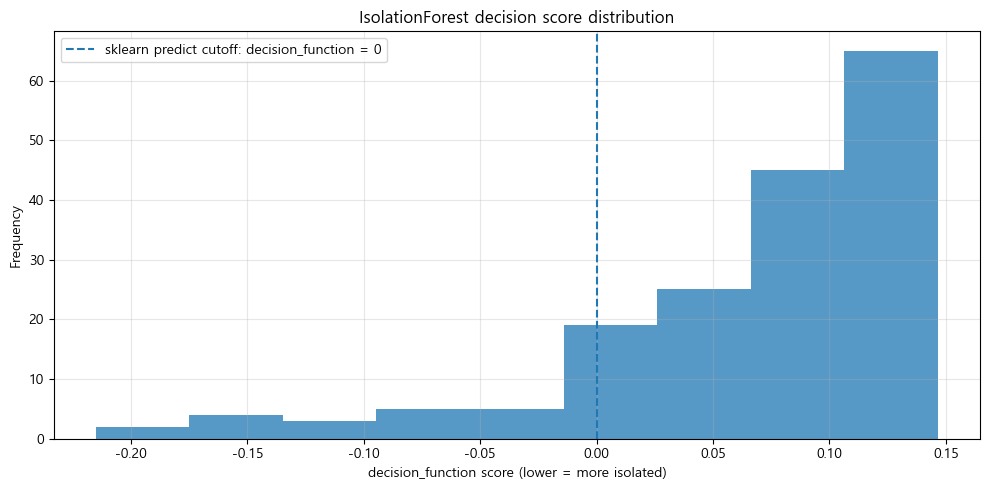

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

iforest_data = session_summary_10m.copy()
iforest_data['log_median_viewer'] = np.log1p(iforest_data['median_viewer'])
iforest_data['log_mean_unique'] = np.log1p(iforest_data['mean_unique'])
iforest_data['log_max_zero_run'] = np.log1p(iforest_data['max_zero_run'])

session_features = [
    'log_median_viewer',
    'zero_chat_rate',
    'median_gap',
    'max_gap',
    'log_mean_unique',
    'log_max_zero_run'
]

iforest_feature_table = pd.DataFrame({
    'feature': session_features,
    'meaning': [
        'session 내부 viewer_count_last 중앙값의 log1p',
        'session 내부 chat_count=0 minute 비율',
        'session 내부 log1p(viewer)-log1p(chat) 중앙값',
        'session 내부 최대 viewer-chat log gap',
        'session 내부 평균 unique_chatters의 log1p',
        'session 내부 최대 연속 0-chat 길이의 log1p'
    ]
})

X_iforest = iforest_data[session_features].replace([np.inf, -np.inf], np.nan)
X_iforest = X_iforest.fillna(X_iforest.median(numeric_only=True))
X_iforest_scaled = RobustScaler().fit_transform(X_iforest)

iso = IsolationForest(random_state=42, contamination='auto')
iforest_data['iforest_label'] = iso.fit_predict(X_iforest_scaled)
iforest_data['iforest_decision_score'] = iso.decision_function(X_iforest_scaled)
iforest_data['iforest_score'] = -iforest_data['iforest_decision_score']

iforest_threshold_summary = pd.DataFrame([{
    'criterion': 'sklearn IsolationForest predict',
    'decision_score_cutoff': 0.0,
    'flag_condition': 'decision_function < 0',
    'flagged_label': -1,
    'n_flagged_sessions': int((iforest_data['iforest_label'] == -1).sum()),
    'n_total_sessions': int(len(iforest_data))
}])

print('IsolationForest flagged session count:', int((iforest_data['iforest_label'] == -1).sum()))
display(iforest_threshold_summary)
display(iforest_feature_table)
display(
    iforest_data.sort_values('iforest_score', ascending=False)[
        SESSION_KEYS + [
            'median_viewer', 'mean_chat', 'zero_chat_rate', 'median_gap',
            'max_gap', 'max_zero_run', 'iforest_decision_score', 'iforest_score', 'iforest_label'
        ]
    ].head(10)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(iforest_data['iforest_decision_score'], bins='sturges', alpha=0.75)
ax.axvline(x=0, linestyle='--', label='sklearn predict cutoff: decision_function = 0')
ax.set_title('IsolationForest decision score distribution')
ax.set_xlabel('decision_function score (lower = more isolated)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig(fig, 'backup_iforest_decision_score_distribution.png')
plt.show()


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>📌 IsolationForest Flag on Review Map</mark></b></span><br><br>

<b>[그래프 목적]</b><br>
기존 session-level bubble plot 위에 IsolationForest가 flag한 세션만 빨간 테두리로 표시한다. 이 그래프는 최종 이상 판정이 아니라 <b>session-level review map</b>이다.<br><br>

<b>[표현 기준]</b><br>
• 전체 대상: 10분 이상 broadcast session<br>
• x축: <code>median_viewer</code><br>
• y축: <code>median_gap</code><br>
• 색: <code>zero_chat_rate</code><br>
• 점 크기: <code>max_gap</code><br>
• 빨간 테두리: <code>IsolationForest.predict()</code>에서 <code>-1</code>로 flag된 session<br><br>

특정 상위 개수를 임의로 라벨링하지 않고, 모델이 flag한 전체 세션만 동일 기준으로 표시한다.
</div>


saved figure: c:\Users\simon\dm_project_2026\eda_slide_plots\slide4_iforest_overlay.png


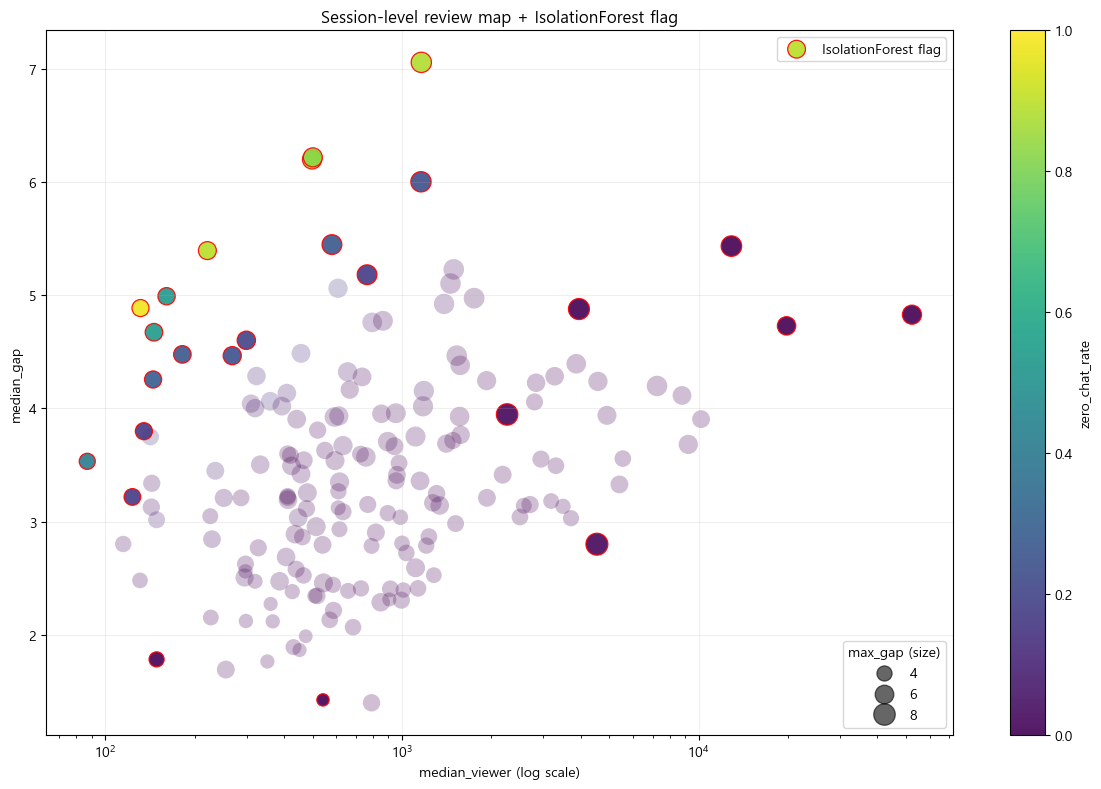

In [23]:
bubble_data = iforest_data.copy()

fig, ax = plt.subplots(figsize=(12, 8))

normal = bubble_data[bubble_data['iforest_label'] == 1]
flagged = bubble_data[bubble_data['iforest_label'] == -1]

c_min, c_max = 0.0, 1.0

ax.scatter(
    normal['median_viewer'],
    normal['median_gap'],
    s=normal['max_gap'].fillna(0) * 30,
    c=normal['zero_chat_rate'].fillna(0),
    cmap='viridis',
    vmin=c_min,
    vmax=c_max,
    alpha=0.25,
    edgecolor='none'
)

sc = ax.scatter(
    flagged['median_viewer'],
    flagged['median_gap'],
    s=flagged['max_gap'].fillna(0) * 30,
    c=flagged['zero_chat_rate'].fillna(0),
    cmap='viridis',
    vmin=c_min,
    vmax=c_max,
    alpha=0.9,
    edgecolor='red',
    linewidth=0.9,
    label='IsolationForest flag'
)

ax.set_title('Session-level review map + IsolationForest flag')
ax.set_xlabel('median_viewer (log scale)')
ax.set_ylabel('median_gap')
ax.set_xscale('log')
ax.grid(True, alpha=0.2)

plt.colorbar(sc, ax=ax, label='zero_chat_rate')

handles, labels = sc.legend_elements(prop='sizes', alpha=0.6, num=4, func=lambda s: np.round(s / 30, 1))
size_legend = ax.legend(handles, labels, loc='lower right', title='max_gap (size)')
ax.add_artist(size_legend)
ax.legend(loc='upper right')

plt.tight_layout()
save_fig(fig, 'slide4_iforest_overlay.png')
plt.show()


In [24]:
save_tables = {
    'pearson_corr': pearson_corr,
    'spearman_corr': spearman_corr,
    'corr_focus': corr_focus,
    'lag_corr': lag_corr,
    'session_audit': session_audit,
    'zero_session_audit': zero_session_audit,
    'session_summary': session_summary,
    'session_summary_10m': session_summary_10m,
    'iforest_data': iforest_data,
    'iforest_threshold_summary': iforest_threshold_summary,
    'iforest_feature_table': iforest_feature_table,
    'kmeans_profile': kmeans_profile,
    'slide1_quality_table': slide1_quality_table,
    'slide2_metric_table': slide2_metric_table,
    'slide3_corr_table': slide3_corr_table,
    'slide4_cluster_selection': slide4_cluster_selection_table,
    'slide4_session_type_profile': slide4_session_type_profile_table
}

COMMON_NOTE = 'session=run_id+broad_no; behavior set=all-zero chat session 제외'

TABLE_NOTE = {
    'pearson_corr': 'minute row 기준 Pearson correlation matrix',
    'spearman_corr': 'minute row 기준 Spearman correlation matrix',
    'corr_focus': 'minute row 기준 핵심 변수쌍 correlation',
    'lag_corr': 'broadcast session 안에서 viewer delta 후 chat/unique delta를 lag별 shift',
    'session_audit': 'user_id+run_id audit용; 최종 EDA 단위는 run_id+broad_no',
    'zero_session_audit': 'broadcast session별 all-zero chat 여부 QC',
    'session_summary': 'broadcast session별 1분 row 요약값',
    'session_summary_10m': '길이 10분 이상 broadcast session 요약값 + session type cluster label',
    'iforest_data': 'IsolationForest predict flag; decision_function<0이면 -1; 최종 판정 아님',
    'iforest_threshold_summary': 'IsolationForest의 0 기준은 sklearn decision_function cutoff',
    'iforest_feature_table': 'IsolationForest에 사용한 session-level feature 정의',
    'kmeans_profile': 'KMeans session type cluster별 session-level 요약 profile',
    'slide4_cluster_selection': 'KMeans k 선택 근거; criterion=silhouette score',
    'slide4_session_type_profile': '오른쪽 슬라이드용 방송 session type profile; clustering 단위=run_id+broad_no'
}


def _add_note_for_excel(sheet_name, table):
    if isinstance(table, pd.Series):
        out = table.to_frame().copy()
    else:
        out = table.copy()

    if 'note' in out.columns:
        return out

    default_note = TABLE_NOTE.get(sheet_name, COMMON_NOTE)

    if sheet_name == 'slide2_metric_table' and 'metric' in out.columns:
        note_map = {
            'median_viewer': '각 session 내부 viewer_count_last 중앙값; 표 값은 session별 값의 median/IQR',
            'mean_chat_per_min': '각 session 내부 chat_count 평균; 표 값은 session별 값의 median/IQR',
            'median_gap': '각 minute의 log1p(viewer)-log1p(chat); session 내부 중앙값',
            'zero_chat_rate': '각 session 안에서 chat_count=0인 minute 비율'
        }
        out['note'] = out['metric'].map(note_map).fillna(default_note)

    elif sheet_name == 'slide3_corr_table' and 'pair' in out.columns:
        note_map = {
            'viewer_log vs chat_log': 'minute row 기준 규모 상관: log1p(viewer_count_last) vs log1p(chat_count)',
            'viewer_log vs unique_log': 'minute row 기준 규모 상관: log1p(viewer_count_last) vs log1p(unique_chatters)',
            'delta_viewer_1m vs delta_chat_1m': '같은 broadcast session 안 전분 대비 변화량 상관',
            'chat_log vs viewer_chat_log_gap': 'gap=log1p(viewer)-log1p(chat); chat이 낮을수록 gap 증가'
        }
        out['note'] = out['pair'].map(note_map).fillna(default_note)

    elif sheet_name == 'slide4_session_type_profile':
        out['note'] = (
            'features=log_median_viewer, log_mean_chat, log_mean_unique, '
            'zero_chat_rate, median_gap, log_max_zero_run; k by silhouette'
        )

    elif sheet_name == 'slide4_cluster_selection':
        out['note'] = 'KMeans k별 silhouette/inertia; 최종 k는 silhouette 최대값 기준'

    else:
        out['note'] = default_note

    return out

with pd.ExcelWriter('dm_project_eda_outputs.xlsx', engine='openpyxl') as writer:
    for sheet_name, table in save_tables.items():
        table_to_save = _add_note_for_excel(sheet_name, table)
        table_to_save = _round_numeric_for_export(table_to_save)
        table_to_save.to_excel(writer, sheet_name=sheet_name[:31], index=True)

    for ws in writer.book.worksheets:
        for row in ws.iter_rows(min_row=2):
            for cell in row:
                if isinstance(cell.value, float):
                    cell.number_format = '0.000'

print('저장 완료: dm_project_eda_outputs.xlsx')


저장 완료: dm_project_eda_outputs.xlsx


In [25]:
from pathlib import Path
import json
import pandas as pd

OUT_DIR = Path.cwd() / "handoff"
OUT_DIR.mkdir(exist_ok=True)

SESSION_KEYS = ["run_id", "broad_no"]

def add_session_key(df):
    out = df.copy()
    out["session_key"] = out["run_id"].astype(str) + "_" + out["broad_no"].astype(str)
    return out

def save_csv(df, name):
    path = OUT_DIR / name
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"{name}: {df.shape}")
    return path

df_all_out = add_session_key(df_all)
df_model_out = add_session_key(df_behavior)
df_zero_out = add_session_key(df_zero_bucket)

df_all_out["is_all_zero_chat_session"] = (
    df_all_out.groupby(SESSION_KEYS)["chat_count"]
    .transform(lambda x: (x == 0).all())
)

df_model_out["is_all_zero_chat_session"] = False
df_zero_out["is_all_zero_chat_session"] = True

session_out = add_session_key(session_summary)

save_csv(df_all_out, "minute_all.csv")
save_csv(df_model_out, "minute_model.csv")
save_csv(df_zero_out, "qc_zero.csv")
save_csv(session_out, "session_all.csv")

optional_tables = {
    "session_10m.csv": globals().get("session_summary_10m"),
    "iforest.csv": globals().get("iforest_data"),
    "cluster.csv": globals().get("cluster_data"),
}

for name, table in optional_tables.items():
    if table is not None:
        save_csv(add_session_key(table), name)

excel_tables = {
    "minute_model": df_model_out,
    "qc_zero": df_zero_out,
    "session_all": session_out,
}

for sheet, table in {
    "session_10m": globals().get("session_summary_10m"),
    "iforest": globals().get("iforest_data"),
    "cluster": globals().get("cluster_data"),
}.items():
    if table is not None:
        excel_tables[sheet] = add_session_key(table)

excel_path = OUT_DIR / "handoff.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet, table in excel_tables.items():
        table.to_excel(writer, sheet_name=sheet[:31], index=False)

meta = {
    "main_file": "minute_model.csv",
    "all_file": "minute_all.csv",
    "qc_file": "qc_zero.csv",
    "session_file": "session_all.csv",
    "unit": {
        "minute_row": "run_id + broad_no + minute_ts",
        "session": "run_id + broad_no"
    },
    "notes": [
        "minute_model.csv excludes all-zero chat sessions and is the recommended modeling start file.",
        "minute_all.csv keeps all rows with is_all_zero_chat_session flag.",
        "qc_zero.csv stores all-zero chat sessions separately.",
        "iforest.csv is a review flag table, not ground-truth anomaly labels.",
        "cluster.csv is a session type table, not bot labels.",
        "Use session_key-based split to avoid leakage."
    ]
}

meta_path = OUT_DIR / "meta.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"handoff.xlsx: {excel_path}")
print(f"meta.json: {meta_path}")
print(f"Done: {OUT_DIR}")

minute_all.csv: (19116, 21)
minute_model.csv: (18457, 21)
qc_zero.csv: (659, 21)
session_all.csv: (176, 15)
session_10m.csv: (173, 22)
iforest.csv: (173, 25)
cluster.csv: (173, 22)
handoff.xlsx: c:\Users\simon\dm_project_2026\handoff\handoff.xlsx
meta.json: c:\Users\simon\dm_project_2026\handoff\meta.json
Done: c:\Users\simon\dm_project_2026\handoff
